<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/cactus_new_thailand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython pysradb cyvcf2 pandas numpy matplotlib scikit-allel statsmodels
!apt-get install ncbi-blast+ -y
!pip install pysam

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ncbi-blast+ is already the newest version (2.12.0+ds-3build1).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.


In [ ]:
!sudo apt-get update
!sudo apt-get install -y fastqc
!sudo apt-get install -y bwa
!sudo apt-get install -y samtools
!sudo apt-get install -y bcftools
!pip install pysradb cyvcf2 scikit-allel matplotlib pandas biopython

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pysradb.sraweb import SRAweb
import pandas as pd

db = SRAweb()

bioprojects = ["PRJNA658467", "PRJNA524330"]

all_meta = []

for bp in bioprojects:
    print("Fetching metadata:", bp)
    meta = db.sra_metadata(bp, detailed=True)
    if meta is not None:
        all_meta.append(meta)

df = pd.concat(all_meta, ignore_index=True)
df = df[['run_accession','sample_accession','experiment_accession','biosample']]

df

/usr/local/lib/python3.12/dist-packages/pysradb/utils.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Fetching metadata: PRJNA658467
Fetching metadata: PRJNA524330


,run_accession,sample_accession,experiment_accession,biosample
0,SRR12549618,SRS7289318,SRX9038918,SAMN15890237
1,SRR12549619,SRS7289277,SRX9038877,SAMN15890240
2,SRR12549620,SRS7289317,SRX9038917,SAMN15890309
3,SRR12549621,SRS7289316,SRX9038916,SAMN15890308
4,SRR12549622,SRS7289315,SRX9038915,SAMN15890236
...,...,...,...,...
88,SRR8633080,SRS4411692,SRX5431774,SAMN11022495
89,SRR8633081,SRS4411693,SRX5431775,SAMN11022493
90,SRR8633082,SRS4411694,SRX5431776,SAMN11022490
91,SRR8633083,SRS4411695,SRX5431777,SAMN11022488


In [ ]:
%%bash
# Install SRA Toolkit if not already installed
sudo apt-get update
sudo apt-get install -y sra-toolkit

mkdir -p sra

for srr in SRR8185310 SRR8185309 SRR10417113; do
    echo "Downloading SRA: $srr"
    prefetch -O sra $srr
done

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  blends-common libkdf5-2 libncbi-vdb2 libncbi-wvdb2 med-config menu
Sugg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 7.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
2025-12-10T12:39:36 prefetch.2.11.3: Current preference is set to retrieve SRA Normalized Format files with full base quality scores.
2025-12-10T12:39:36 prefetch.2.11.3: 1) Downloading 'SRR8185310'...
2025-12-10T12:39:36 prefetch.2.11.3: SRA Normalized Format file is being retrieved, if this is different from your preference, it may be due to current file ava

In [ ]:
%%bash
mkdir -p fastq

for srr in SRR8185310 SRR8185309 SRR10417113; do
    echo "Converting $srr"
    fasterq-dump sra/$srr --split-files -O fastq

    # If paired-end files exist, gzip them
    if [ -f fastq/${srr}_1.fastq ]; then
        echo "Detected paired-end for $srr"
        gzip fastq/${srr}_1.fastq
        gzip fastq/${srr}_2.fastq

    # Otherwise gzip single-end file
    elif [ -f fastq/${srr}.fastq ]; then
        echo "Detected single-end for $srr"
        gzip fastq/${srr}.fastq
    else
        echo "ERROR: No FASTQ produced for $srr"
    fi
done


Converting SRR8185310
Detected single-end for SRR8185310
Converting SRR8185309
Detected single-end for SRR8185309
Converting SRR10417113
Detected paired-end for SRR10417113


spots read      : 4,594,560
reads read      : 4,594,560
reads written   : 4,594,560
spots read      : 15,990,232
reads read      : 15,990,232
reads written   : 15,990,232
spots read      : 8,645,996
reads read      : 17,291,992
reads written   : 17,291,992


In [ ]:
!apt-get update -qq
!apt-get install -y fastqc
!pip install multiqc
import os
import glob

# Create output folder
os.makedirs("qc_reports", exist_ok=True)

# List all fastq.gz files
fastq_files = glob.glob("fastq/*.gz")

print("FASTQ files detected:")
for f in fastq_files:
    print(" -", f)

# Run FastQC for each file
for f in fastq_files:
    print(f"\nRunning FastQC on: {f}")
    !fastqc "{f}" -o qc_reports


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fastqc is already the newest version (0.11.9+dfsg-5).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
!multiqc qc_reports -o qc_reports


/// ]8;id=326659;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /content/qc_reports
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 8/8  
            fastqc | Found 4 reports
     write_results | Data        : qc_reports/multiqc_data
     write_results | Report      : qc_reports/multiqc_report.html
           multiqc | MultiQC complete


In [ ]:
!mkdir -p reference
!wget -O reference/opuntia.fasta "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/001/595/765/GCA_001595765.1_ASM159576v1/GCA_001595765.1_ASM159576v1_genomic.fna.gz"
!gunzip reference/opuntia.fasta.gz

--2025-12-10 13:17:04--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/001/595/765/GCA_001595765.1_ASM159576v1/GCA_001595765.1_ASM159576v1_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-12-10 13:17:05 ERROR 404: Not Found.

gzip: reference/opuntia.fasta.gz: No such file or directory


In [ ]:
%%bash
mkdir -p reference
wget -O reference/opuntia.fasta "https://www.ncbi.nlm.nih.gov/sviewer/viewer.cgi?tool=nuccore&report=fasta&id=NC_034960.1"

--2025-12-10 13:17:05--  https://www.ncbi.nlm.nih.gov/sviewer/viewer.cgi?tool=nuccore&report=fasta&id=NC_034960.1
Resolving www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)... 130.14.29.110, 2607:f220:41e:4290::110
Connecting to www.ncbi.nlm.nih.gov (www.ncbi.nlm.nih.gov)|130.14.29.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘reference/opuntia.fasta’

     0K .......... .......... .......... .......... ..........  433K
    50K .......... .......... .......... .......... .......... 10.1M
   100K .......... .......... .......... .......... ..........  922K
   150K .......... .......... .......... .......... ..........  158M
   200K .......... .......... .......... .......... ..........  881K
   250K .......... .......... .......... .......... .......... 15.6M
   300K .......... .......... .......... .......... .......... 39.1M
   350K .......... .......... .......... .......... .......... 45.3M
   400K .......... ..........

In [ ]:
!apt-get install -y bwa samtools
!wget https://github.com/bwa-mem2/bwa-mem2/releases/download/v2.2.1/bwa-mem2-2.2.1_x64-linux.tar.bz2
!tar -xjf bwa-mem2-2.2.1_x64-linux.tar.bz2
!cp bwa-mem2-2.2.1_x64-linux/* /usr/local/bin/
!bwa-mem2 index reference/opuntia.fasta

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
bwa is already the newest version (0.7.17-6).
samtools is already the newest version (1.13-4).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.
--2025-12-10 13:17:15--  https://github.com/bwa-mem2/bwa-mem2/releases/download/v2.2.1/bwa-mem2-2.2.1_x64-linux.tar.bz2
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/172733240/e15d8e80-8715-11eb-9e9e-cdbee002fcfc?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-10T14%3A06%3A29Z&rscd=attachment%3B+filename%3Dbwa-mem2-2.2.1_x64-linux.tar.bz2&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-10T13%3A05%3A39Z&ske=2025-12-10T14%3A06%3A29Z&sks=b&skv=2018-11-0

In [ ]:
import glob

fastq_files = sorted(glob.glob("fastq/*.gz"))
print("FASTQ files:", fastq_files)


FASTQ files: ['fastq/SRR10417113_1.fastq.gz', 'fastq/SRR10417113_2.fastq.gz', 'fastq/SRR8185309.fastq.gz', 'fastq/SRR8185310.fastq.gz']


In [ ]:
%%bash
apt-get update -qq
apt-get install -y samtools

# Install BWA-MEM2
wget https://github.com/bwa-mem2/bwa-mem2/releases/latest/download/bwa-mem2-2.2.1_x64-linux.tar.bz2
tar -xjf bwa-mem2-2.2.1_x64-linux.tar.bz2

# Move binaries to /usr/local/bin so Colab can find them
cp bwa-mem2-2.2.1_x64-linux/* /usr/local/bin/

# Verify installation
which bwa-mem2
bwa-mem2 version

Reading package lists...
Building dependency tree...
Reading state information...
samtools is already the newest version (1.13-4).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.
/usr/local/bin/bwa-mem2
2.2.1


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
--2025-12-10 13:17:27--  https://github.com/bwa-mem2/bwa-mem2/releases/latest/download/bwa-mem2-2.2.1_x64-linux.tar.bz2
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/bwa-mem2/bwa-mem2/releases/download/v2.3/bwa-mem2-2.2.1_x64-linux.tar.bz2 [following]
--2025-12-10 13:17:27--  https://github.com/bwa-mem2/bwa-mem2/releases/download/v2.3/bwa-mem2-2.2.1_x64-linux.tar.bz2
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 404 Not Found
2025-12-10 13:17:27 ERROR 404: Not Found.

Looking to launch executable "/usr/local/bin/bwa-mem2.avx2", simd = .avx2
Launching executable "/usr/local/bin/bwa-mem2.avx2"


In [ ]:
%%bash
bwa-mem2 index reference/opuntia.fasta

ref_seq_len = 2649354
count = 0, 690231, 1324677, 1959123, 2649354
BWT[933258] = 4
CP_SHIFT = 6, CP_MASK = 63
sizeof CP_OCC = 64
max_occ_ind = 41396


Looking to launch executable "/usr/local/bin/bwa-mem2.avx2", simd = .avx2
Launching executable "/usr/local/bin/bwa-mem2.avx2"
[bwa_index] Pack FASTA... 0.01 sec
* Entering FMI_search
init ticks = 169438311
ref seq len = 2649354
binary seq ticks = 82021738
build suffix-array ticks = 800100986
pos: 331170, ref_seq_len__: 331169
build fm-index ticks = 235680841
Total time taken: 0.6326


In [ ]:
import os
import glob

os.makedirs("aligned", exist_ok=True)

# Identify unique SRR prefixes
samples = sorted(set([f.split("/")[-1].split("_")[0].split(".")[0] for f in fastq_files]))
print("Samples:", samples)

for srr in samples:
    print("\n=== Processing sample:", srr, "===")

    pe1 = f"fastq/{srr}_1.fastq.gz"
    pe2 = f"fastq/{srr}_2.fastq.gz"
    se = f"fastq/{srr}.fastq.gz"

    bam_out = f"aligned/{srr}.sorted.bam"

    # Paired-end
    if os.path.exists(pe1) and os.path.exists(pe2):
        print("Detected paired-end FASTQ")
        !bwa-mem2 mem -t 8 reference/opuntia.fasta {pe1} {pe2} | samtools sort -o {bam_out}

    # Single-end
    elif os.path.exists(se):
        print("Detected single-end FASTQ")
        !bwa-mem2 mem -t 8 reference/opuntia.fasta {se} | samtools sort -o {bam_out}

    else:
        print("FASTQ not found for sample:", srr)
        continue

    print("Indexing BAM:", bam_out)
    !samtools index {bam_out}


Samples: ['SRR10417113', 'SRR8185309', 'SRR8185310']

=== Processing sample: SRR10417113 ===
Detected paired-end FASTQ
Looking to launch executable "/usr/local/bin/bwa-mem2.avx2", simd = .avx2
Launching executable "/usr/local/bin/bwa-mem2.avx2"
-----------------------------
Executing in AVX2 mode!!
-----------------------------
* SA compression enabled with xfactor: 8
* Ref file: reference/opuntia.fasta
* Entering FMI_search
* Index file found. Loading index from reference/opuntia.fasta.bwt.2bit.64
* Reference seq len for bi-index = 2649355
* sentinel-index: 933258
* Count:
0,	1
1,	690232
2,	1324678
3,	1959124
4,	2649355

* Reading other elements of the index from files reference/opuntia.fasta
* Index prefix: reference/opuntia.fasta
* Read 0 ALT contigs
* Done reading Index!!
* Reading reference genome..
* Binary seq file = reference/opuntia.fasta.0123
* Reference genome size: 2649354 bp
* Done reading reference genome !!

------------------------------------------
1. Memory pre-alloca

In [ ]:
%%bash
mkdir -p variants

# Make BAM list
ls aligned/*.sorted.bam > bam_list.txt

# Generate BCF with mpileup
bcftools mpileup -Ou -f reference/opuntia.fasta -b bam_list.txt \
    --threads 8 \
    | bcftools call -mv -Ov -o variants/raw.vcf


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 3 samples in 3 input files
[mpileup] maximum number of reads per input file set to -d 250


In [ ]:
%%bash
bcftools filter -i 'QUAL>20 && DP>5' variants/raw.vcf > variants/filtered.vcf


In [ ]:
!grep -v '^#' variants/filtered.vcf | wc -l


9


In [ ]:
%%bash
mkdir -p reference

BASE="https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/002/910/715/GCF_002910715.1_O_ficus-indica_cp_v1"

echo "Downloading Opuntia ficus-indica chloroplast FASTA + GFF3"

wget -O reference/opuntia.fasta.gz \
"$BASE/GCF_002910715.1_O_ficus-indica_cp_v1_genomic.fna.gz"

wget -O reference/opuntia.gff3.gz \
"$BASE/GCF_002910715.1_O_ficus-indica_cp_v1_genomic.gff.gz"

gunzip -f reference/opuntia.fasta.gz
gunzip -f reference/opuntia.gff3.gz

echo "Download completed"
ls -lh reference


Download completed
total 8.3M
-rw-r--r-- 1 root root 1.3M Dec 10 13:17 opuntia.fasta
-rw-r--r-- 1 root root 2.6M Dec 10 13:17 opuntia.fasta.0123
-rw-r--r-- 1 root root   12 Dec 10 13:17 opuntia.fasta.amb
-rw-r--r-- 1 root root   97 Dec 10 13:17 opuntia.fasta.ann
-rw-r--r-- 1 root root 4.2M Dec 10 13:17 opuntia.fasta.bwt.2bit.64
-rw-r--r-- 1 root root   29 Dec 10 13:37 opuntia.fasta.fai
-rw-r--r-- 1 root root    0 Dec 10 13:37 opuntia.fasta.gz
-rw-r--r-- 1 root root 324K Dec 10 13:17 opuntia.fasta.pac
-rw-r--r-- 1 root root    0 Dec 10 13:37 opuntia.gff3.gz


--2025-12-10 13:37:37--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/002/910/715/GCF_002910715.1_O_ficus-indica_cp_v1/GCF_002910715.1_O_ficus-indica_cp_v1_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-12-10 13:37:37 ERROR 404: Not Found.

--2025-12-10 13:37:37--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/002/910/715/GCF_002910715.1_O_ficus-indica_cp_v1/GCF_002910715.1_O_ficus-indica_cp_v1_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-12-10 13:37:37 ERROR 404: Not Found.


gzip: reference/opuntia.fasta.gz: unexpected end of file

gzip: refer

In [ ]:
rm reference/opuntia.fasta*


In [ ]:
%%bash
mkdir -p reference

# Download Opuntia ficus-indica chloroplast genome in FASTA format
wget -O reference/opuntia.fasta "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_034960.1&rettype=fasta&retmode=text"

# Download its annotation (GFF3)
wget -O reference/opuntia.gff3 "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_034960.1&rettype=gff3&retmode=text"

echo "Downloaded files:"
ls -lh reference


Downloaded files:
total 3.1M
-rw-r--r-- 1 root root 1.3M Dec 10 13:37 opuntia.fasta
-rw-r--r-- 1 root root 1.8M Dec 10 13:37 opuntia.gff3
-rw-r--r-- 1 root root    0 Dec 10 13:37 opuntia.gff3.gz


--2025-12-10 13:37:38--  https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_034960.1&rettype=fasta&retmode=text
Resolving eutils.ncbi.nlm.nih.gov (eutils.ncbi.nlm.nih.gov)... 130.14.29.110, 2607:f220:41e:4290::110
Connecting to eutils.ncbi.nlm.nih.gov (eutils.ncbi.nlm.nih.gov)|130.14.29.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘reference/opuntia.fasta’

     0K .......... .......... .......... .......... ..........  429K
    50K .......... .......... .......... .......... ..........  858K
   100K .......... .......... .......... .......... ..........  135M
   150K .......... .......... .......... .......... ..........  115M
   200K .......... .......... .......... .......... ..........  866K
   250K .......... .......... .......... .......... ..........  123M
   300K .......... .......... .......... .......... ..........  117M
   350K .......... .......... .......... .......... ..........  

In [ ]:
%%bash
# Create new genome folder
mkdir -p snpEff/data/opuntia_cp

# Copy files into SnpEff structure
cp reference/opuntia.fasta snpEff/data/opuntia_cp/sequences.fa
cp reference/opuntia.gff3  snpEff/data/opuntia_cp/genes.gff

echo "Files in snpEff/data/opuntia_cp:"
ls -lh snpEff/data/opuntia_cp


Files in snpEff/data/opuntia_cp:
total 3.1M
-rw-r--r-- 1 root root 1.8M Dec 10 13:37 genes.gff
-rw-r--r-- 1 root root 1.3M Dec 10 13:37 sequences.fa


In [ ]:
%%bash
# Remove old entry if any
sed -i '/opuntia_cp.genome/d' snpEff/snpEff.config

# Add new genome entry
echo "opuntia_cp.genome : Opuntia_ficus_indica_chloroplast" >> snpEff/snpEff.config

# Set plastid codon table
echo "opuntia_cp.codonTable : Bacterial_and_Plant_Plastid_Code" >> snpEff/snpEff.config

echo "Updated snpEff.config:"
grep "opuntia_cp" snpEff/snpEff.config


Updated snpEff.config:
opuntia_cp.genome : Opuntia_ficus_indica_chloroplast
opuntia_cp.codonTable : Bacterial_and_Plant_Plastid_Code


sed: can't read snpEff/snpEff.config: No such file or directory


In [ ]:
%%bash
# Remove incorrect codon table entry
sed -i '/opuntia_cp.codonTable/d' snpEff/snpEff.config

# Add valid chloroplast codon table
echo "opuntia_cp.codonTable : Chloroplast" >> snpEff/snpEff.config

# Show updated entry
grep "opuntia_cp" snpEff/snpEff.config


opuntia_cp.genome : Opuntia_ficus_indica_chloroplast
opuntia_cp.codonTable : Chloroplast


In [ ]:
%%bash
sed -i '/opuntia_cp.codonTable/d' snpEff/snpEff.config


In [ ]:
!grep -n "opuntia_cp" -n snpEff/snpEff.config


1:opuntia_cp.genome : Opuntia_ficus_indica_chloroplast


In [ ]:
%%bash
cd snpEff
java -Xmx4g -jar snpEff.jar build -gff3 -v opuntia_cp


Error: Unable to access jarfile snpEff.jar


CalledProcessError: Command 'b'cd snpEff\njava -Xmx4g -jar snpEff.jar build -gff3 -v opuntia_cp\n'' returned non-zero exit status 1.

In [ ]:
%%bash
java -Xmx4g -jar snpEff/snpEff.jar opuntia_cp variants/filtered.vcf > variants/annotated.vcf


Error: Unable to access jarfile snpEff/snpEff.jar


CalledProcessError: Command 'b'java -Xmx4g -jar snpEff/snpEff.jar opuntia_cp variants/filtered.vcf > variants/annotated.vcf\n'' returned non-zero exit status 1.

In [ ]:
%%bash
grep -v '^#' variants/annotated.vcf | \
awk -F'\t' '
{
    split($8,ann,"ANN=");
    split(ann[2],ann2,"|");
    print $1"\t"$2"\t"$4"\t"$5"\t"ann2[2]"\t"ann2[3]"\t"ann2[4]"\t"ann2[5];
}' \
> variants/annotated.tsv


In [ ]:
%%bash
echo -e "CHROM\tPOS\tREF\tALT\tEFFECT\tIMPACT\tGENE_NAME\tGENE_ID" > variants/table.tsv
cat variants/annotated.tsv >> variants/table.tsv


In [ ]:
%%bash
sed 's/\t/,/g' variants/annotated.tsv > variants/annotated.csv


In [ ]:
%%bash
ls -lh variants/
echo "----"
grep -v '^#' variants/annotated.vcf | head


total 20K
-rw-r--r-- 1 root root    0 Dec 10 13:39 annotated.csv
-rw-r--r-- 1 root root    0 Dec 10 13:39 annotated.tsv
-rw-r--r-- 1 root root    0 Dec 10 13:39 annotated.vcf
-rw-r--r-- 1 root root 4.4K Dec 10 13:37 filtered.vcf
-rw-r--r-- 1 root root 4.4K Dec 10 13:37 raw.vcf
-rw-r--r-- 1 root root   50 Dec 10 13:39 table.tsv
----


In [ ]:
%%bash
awk '
BEGIN {
    OFS=",";
    print "Chrom,Position,Ref,Alt,Effect,Impact,Gene_Name,Gene_ID,Transcript,Protein,AA_Change,Codon_Change";
}
!/^#/ {
    split($8, info, ";");

    ann_field = "";
    for (i in info) {
        if (info[i] ~ /^ANN=/) {
            ann_field = substr(info[i], 5);
            break;
        }
    }

    split(ann_field, ann_entries, ",");
    split(ann_entries[1], ann, "|");

    chrom   = $1;
    pos     = $2;
    ref     = $4;
    alt     = $5;

    effect        = ann[2];
    impact        = ann[3];
    gene_name     = ann[4];
    gene_id       = ann[5];
    transcript    = ann[7];
    protein       = ann[10];
    aa_change     = ann[11];
    codon_change  = ann[10];

    print chrom, pos, ref, alt, effect, impact, gene_name, gene_id, transcript, protein, aa_change, codon_change;
}' variants/annotated.vcf > variants/annotated.csv


In [ ]:
%%bash
head -n 20 variants/annotated.vcf | grep -v "^##" | head -n 1 | awk '{for (i=1;i<=NF;i++) print i,$i}'


In [ ]:
%%bash
ls -lh variants/


total 24K
-rw-r--r-- 1 root root   97 Dec 10 13:39 annotated.csv
-rw-r--r-- 1 root root    0 Dec 10 13:39 annotated.tsv
-rw-r--r-- 1 root root    0 Dec 10 13:39 annotated.vcf
-rw-r--r-- 1 root root 4.4K Dec 10 13:37 filtered.vcf
-rw-r--r-- 1 root root 4.4K Dec 10 13:37 raw.vcf
-rw-r--r-- 1 root root   50 Dec 10 13:39 table.tsv


In [ ]:
%%bash
grep -v "^#" variants/annotated.vcf | wc -l


0


In [ ]:
%%bash
grep "ANN=" variants/annotated.vcf | head


In [ ]:
%%bash
awk '
BEGIN {
    OFS=",";
    print "Chrom,Position,Ref,Alt,Effect,Impact,Gene_Name,Gene_ID,Transcript,Protein,AA_Change,Codon_Change";
}
!/^#/ {
    # Extract ANN=... field
    ann="";
    n = split($8, info, ";");
    for (i=1; i<=n; i++) {
        if (info[i] ~ /^ANN=/) {
            ann = substr(info[i], 5);
            break;
        }
    }
    if (ann == "") next;

    # For each comma-separated ANN entry
    m = split(ann, entries, ",");

    for (j = 1; j <= m; j++) {
        split(entries[j], f, "|");

        effect       = f[2];
        impact       = f[3];
        gene_name    = f[4];
        gene_id      = f[5];
        transcript   = f[7];
        protein      = f[10];
        aa_change    = f[11];
        codon_change = f[10];

        print $1, $2, $4, $5, effect, impact, gene_name, gene_id, transcript, protein, aa_change, codon_change;
    }
}' variants/annotated.vcf > variants/annotated.csv

echo "DONE → variants/annotated.csv"


DONE → variants/annotated.csv


In [ ]:
%%bash
wc -l variants/annotated.csv
head variants/annotated.csv


1 variants/annotated.csv
Chrom,Position,Ref,Alt,Effect,Impact,Gene_Name,Gene_ID,Transcript,Protein,AA_Change,Codon_Change


In [ ]:
%%bash
awk '
BEGIN {
    OFS=",";
    print "Chrom,Position,Ref,Alt,Effect,Impact,Gene_Name,Gene_ID,Transcript,AA_Change,Codon_Change";
}

# Skip header lines
/^#/ { next }

{
    chrom = $1;
    pos   = $2;
    ref   = $4;
    alt   = $5;

    # Extract ANN=
    ann_field = "";
    split($8, info, ";");
    for (i in info) {
        if (info[i] ~ /^ANN=/) {
            ann_field = substr(info[i], 5);
            break;
        }
    }

    # Split into individual annotations
    n = split(ann_field, ann_entries, ",");

    best_impact_rank = 999;   # large number
    best_entry = "";

    # Ranking: lower number = higher priority
    for (i = 1; i <= n; i++) {
        split(ann_entries[i], ann, "|");

        effect = ann[2];
        impact = ann[3];

        # Ranking system
        if      (impact == "HIGH")      rank = 1;
        else if (impact == "MODERATE")  rank = 2;
        else if (impact == "LOW")       rank = 3;
        else                            rank = 4;  # MODIFIER

        if (rank < best_impact_rank) {
            best_impact_rank = rank;
            best_entry = ann_entries[i];
        }
    }

    # Parse best entry
    split(best_entry, a, "|");

    effect        = a[2];
    impact        = a[3];
    gene_name     = a[4];
    gene_id       = a[5];
    transcript    = a[7];
    aa_change     = a[11];
    codon_change  = a[10];

    print chrom, pos, ref, alt, effect, impact, gene_name, gene_id, transcript, aa_change, codon_change;
}' variants/annotated.vcf > variants/annotated_best.csv


In [ ]:
%%bash
wc -l variants/annotated_best.csv
head variants/annotated_best.csv


1 variants/annotated_best.csv
Chrom,Position,Ref,Alt,Effect,Impact,Gene_Name,Gene_ID,Transcript,AA_Change,Codon_Change


In [ ]:
ls -R .


.:
aligned/                          drive/       sample_data/
bam_list.txt                      fastq/       snpEff/
bwa-mem2-2.2.1_x64-linux/         qc_reports/  sra/
bwa-mem2-2.2.1_x64-linux.tar.bz2  reference/   variants/

./aligned:
SRR10417113.sorted.bam      SRR8185309.sorted.bam.bai
SRR10417113.sorted.bam.bai  SRR8185310.sorted.bam
SRR8185309.sorted.bam       SRR8185310.sorted.bam.bai

./bwa-mem2-2.2.1_x64-linux:
bwa-mem2*      bwa-mem2.avx2*      bwa-mem2.sse41*  LICENSE  README.md
bwa-mem2.avx*  bwa-mem2.avx512bw*  bwa-mem2.sse42*  NEWS.md  README-ori.md

./drive:
MyDrive/

./drive/MyDrive:
 10.docx
 10.pdf
 11.docx
 11.pdf
'1212 (1).jpg'
 1212.jpg
 12.docx
 12.pdf
 13.docx
 13.pdf
 14.docx
 14.pdf
 15.docm
 15.pdf
 16.docx
 16.pdf
 1747240427.pdf
 176458229533081396258642495089.jpg
 17.doc
 17.pdf
 18.docx
 18.pdf
 19.docx
 19.pdf
 1.docm
 1.jpg
 1.pdf
 20.docx
 20.pdf
 21.docx
 21.pdf
 2.docx
 2.pdf
 3.docx
 3.pdf
 461584-001-Certificate.pdf
 4.docx
 4.pdf
 5.docx
 5.pdf
 

In [ ]:
!pip install pandas matplotlib --quiet


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==== Input & Output Paths ====
INPUT_CSV = "/content/variants/annotated.csv"
OUT_DIR = "/content/results"
TOP_N = 40  # number of top genes to show in bar plot

os.makedirs(OUT_DIR, exist_ok=True)

# ==== Load CSV ====
df = pd.read_csv(INPUT_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]   # cleanup headers

# ==== Required Columns Check ====
required_cols = {"Chrom","Position","Ref","Alt","Effect","Impact","Gene_Name"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Convert Position to int
df["Position"] = df["Position"].astype(int)

# Replace empty gene names
df["Gene_Name"] = df["Gene_Name"].fillna("INTERGENIC").replace("", "INTERGENIC")

# ==== Unique mutation count per gene ====
gene_counts = (
    df.groupby("Gene_Name")["Position"]
    .nunique()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

# Save table
gene_counts.to_csv(f"{OUT_DIR}/gene_counts.csv", index=False)

# ==== Plot top N genes ====
plot_df = gene_counts.head(TOP_N)

plt.figure(figsize=(14, 6))
plt.bar(plot_df["Gene_Name"], plot_df["Mutation_Count"])
plt.xticks(rotation=90)
plt.title(f"Top {TOP_N} Genes with Most Unique Mutations")
plt.xlabel("Gene Name")
plt.ylabel("Unique Mutation Count")
plt.tight_layout()

plot_path = f"{OUT_DIR}/gene_mutation_counts.png"
plt.savefig(plot_path)
plt.close()

print("✔ Gene-wise mutation count table saved to:", f"{OUT_DIR}/gene_counts.csv")
print("✔ Plot saved to:", plot_path)
print("\nTop 10 genes:\n")
print(gene_counts.head(10))


✔ Gene-wise mutation count table saved to: /content/results/gene_counts.csv
✔ Plot saved to: /content/results/gene_mutation_counts.png

Top 10 genes:

Empty DataFrame
Columns: [Gene_Name, Mutation_Count]
Index: []


In [ ]:
import os
import pandas as pd

INPUT_CSV = "/content/variants/annotated.csv"
OUT_DIR = "/content/results"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

# Ensure required columns
required_cols = {"Chrom","Position","Ref","Alt","Effect","Impact"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ---- Select High Impact by SnpEff ----
high1 = df[df["Impact"].str.upper() == "HIGH"]

# ---- Select Serious Effects even if Impact != HIGH ----
serious_effects = {
    "stop_gained",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "start_lost",
    "stop_lost",
    "frameshift_variant",
    "transcript_ablation"
}

high2 = df[df["Effect"].str.lower().isin(serious_effects)]

# Combine both sets
high_all = pd.concat([high1, high2]).drop_duplicates(subset=["Chrom","Position","Ref","Alt"])

# Save output
output_file = f"{OUT_DIR}/high_impact_snps.csv"
high_all.to_csv(output_file, index=False)

print("✔ High-impact SNPs saved to:", output_file)
print("Total high-impact SNPs:", len(high_all))
print("\nPreview:\n")
print(high_all.head(10))


✔ High-impact SNPs saved to: /content/results/high_impact_snps.csv
Total high-impact SNPs: 0

Preview:

Empty DataFrame
Columns: [Chrom, Position, Ref, Alt, Effect, Impact, Gene_Name, Gene_ID, Transcript, Protein, AA_Change, Codon_Change]
Index: []


In [ ]:
# Colab-ready: Interactive report + Volcano + Functional categories + Manhattan + GO enrichment
# Paste and run as one cell.

# 0) Install dependencies (may take a minute)
!pip install -q pandas plotly ydata-profiling==4.2.0 gffutils goatools matplotlib seaborn

# 1) Imports
import os, sys, math, gzip, re
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

os.makedirs("/content/results", exist_ok=True)

# 2) Paths (update if necessary)
ANNOTATED_CSV = "/content/variants/annotated.csv"       # your earlier CSV
ANNOTATED_VCF = "/content/variants/annotated.vcf"       # SnpEff annotated VCF
GFF3_PATH      = "/content/reference/opuntia.gff3"     # reference GFF (optional)

# 3) Load annotated.csv (primary source)
if not os.path.exists(ANNOTATED_CSV):
    raise FileNotFoundError(f"Cannot find {ANNOTATED_CSV} - adjust path")

df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

# Basic cleanup
if "Position" in df.columns:
    df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
else:
    df["Position"] = np.nan

# Standardize columns
for c in ["Chrom","Ref","Alt","Effect","Impact","Gene_Name"]:
    if c not in df.columns:
        df[c] = ""

# 4) Attempt to read QUAL / INFO from annotated.vcf and merge (if available)
if os.path.exists(ANNOTATED_VCF):
    vcf_rows = []
    with open(ANNOTATED_VCF, "r") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 8:
                continue
            chrom, pos, vid, ref, alt, qual, filt, info = parts[:8]
            try:
                qual_val = float(qual) if qual != "." else np.nan
            except:
                qual_val = np.nan
            # extract DP or AF if present
            info_map = {}
            for kv in info.split(";"):
                if "=" in kv:
                    k,v = kv.split("=",1)
                    info_map[k] = v
            dp = info_map.get("DP", np.nan)
            vcf_rows.append({"Chrom":chrom, "Position":int(pos), "Ref":ref, "Alt":alt, "QUAL":qual_val, "DP":dp, "INFO":info})
    vdf = pd.DataFrame(vcf_rows)
    # merge with annotated CSV on Chrom+Position+Ref+Alt (best-effort)
    # there may be multiple alt alleles — do a lenient merge on chrom+pos
    merged = pd.merge(df, vdf, how="left", left_on=["Chrom","Position"], right_on=["Chrom","Position"])
    df = merged
else:
    df["QUAL"] = np.nan
    df["DP"] = np.nan

# 5) Create numeric "effect score" and significance proxy for plotting
impact_map = {"HIGH":3, "MODERATE":2, "LOW":1, "MODIFIER":0}
df["Impact_norm"] = df["Impact"].str.upper().map(impact_map).fillna(0).astype(int)

# Convert QUAL -> -log10(p) proxy:
# QUAL is phred-like; p_error = 10^(-QUAL/10); so -log10(p_error) = QUAL/10
df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
df["sig_proxy"] = df["QUAL"] / 10.0   # higher is more significant (proxy)

# Fill missing gene names
df["Gene_Name"] = df["Gene_Name"].fillna("INTERGENIC").replace("", "INTERGENIC")

# 6) Interactive HTML report using ydata-profiling
print("Generating interactive profiling report (ydata-profiling)...")
profile = ProfileReport(df, title="Variants interactive report", minimal=False)
html_report_path = "/content/results/variants_profile_report.html"
profile.to_file(html_report_path)
print("Saved:", html_report_path)

# 7) Volcano-like plot
# We'll treat x = Impact_norm (categorical-ish) + jitter; y = sig_proxy
print("Building volcano-like plot...")
df_vol = df.copy()
# use a small jitter for x so points spread
np.random.seed(0)
df_vol["x"] = df_vol["Impact_norm"] + (np.random.rand(len(df_vol)) - 0.5) * 0.3
df_vol["y"] = df_vol["sig_proxy"].fillna(0)

fig_v = px.scatter(df_vol, x="x", y="y", color="Impact",
                   hover_data=["Chrom","Position","Ref","Alt","Gene_Name","Effect","Impact","QUAL","DP"],
                   title="Volcano-like plot (Impact score vs significance proxy)",
                   labels={"x":"Impact score (numeric)", "y":"-log10(p) proxy (QUAL/10)"})
# annotate thresholds
fig_v.add_hline(y=5, line_dash="dash", line_color="gray", annotation_text="sig proxy = 5 (QUAL=50)", annotation_position="top left")
fig_v.write_html("/content/results/volcano_plot.html")
print("Saved:", "/content/results/volcano_plot.html")

# 8) Functional category plots (Effect + Impact counts)
print("Generating functional category plots...")
effect_counts = df["Effect"].fillna("UNKNOWN").value_counts().reset_index()
effect_counts.columns = ["Effect","Count"]
imp_counts = df["Impact"].fillna("UNKNOWN").value_counts().reset_index()
imp_counts.columns = ["Impact","Count"]

fig_eff = px.bar(effect_counts, x="Effect", y="Count", title="Mutation counts by Effect (SnpEff)")
fig_imp = px.bar(imp_counts, x="Impact", y="Count", title="Mutation counts by Impact (SnpEff)")

fig_eff.write_html("/content/results/effect_counts.html")
fig_imp.write_html("/content/results/impact_counts.html")
print("Saved:", "/content/results/effect_counts.html")
print("Saved:", "/content/results/impact_counts.html")

# 9) Chromosomal Manhattan plot (position vs significance)
print("Generating chromosomal Manhattan plot...")
# If Chrom strings look like NC_* (single chromosome), we'll still plot by Chrom
df_manh = df.copy()
df_manh = df_manh.dropna(subset=["Position"])
# if sig_proxy missing, set small value
df_manh["y"] = df_manh["sig_proxy"].fillna(0.1)

# build a continuous x by concatenating chromosomes in order
chrom_order = sorted(df_manh["Chrom"].unique())
chrom_offsets = {}
offset = 0
ticks = []
for ch in chrom_order:
    ch_df = df_manh[df_manh["Chrom"]==ch]
    if ch_df.empty:
        continue
    minpos = int(ch_df["Position"].min())
    maxpos = int(ch_df["Position"].max())
    chrom_offsets[ch] = offset
    ticks.append((offset + (maxpos - minpos)/2, ch))
    offset += (maxpos - minpos) + 1000  # small gap

df_manh["x_global"] = df_manh.apply(lambda r: chrom_offsets.get(r["Chrom"],0) + r["Position"], axis=1)

fig_m = px.scatter(df_manh, x="x_global", y="y", color="Chrom",
                   hover_data=["Chrom","Position","Ref","Alt","Gene_Name","Effect","Impact","QUAL"],
                   title="Chromosomal Manhattan-like plot (position vs significance proxy)",
                   labels={"y":"-log10(p) proxy (QUAL/10)"})
# add chromosome ticks
fig_m.update_xaxes(tickmode='array', tickvals=[t[0] for t in ticks], ticktext=[t[1] for t in ticks])
fig_m.add_hline(y=5, line_dash="dash", line_color="gray", annotation_text="sig proxy=5", annotation_position="top left")
fig_m.write_html("/content/results/manhattan_plot.html")
print("Saved:", "/content/results/manhattan_plot.html")

# 10) Gene-wise mutation counts (again) and plot (static)
print("Generating gene-wise mutation counts (.csv + png)...")
gene_counts = df.groupby("Gene_Name").agg(Mutation_Count=("Position", lambda x: x.nunique())).reset_index().sort_values("Mutation_Count", ascending=False)
gene_counts.to_csv("/content/results/gene_counts.csv", index=False)

plt.figure(figsize=(12,6))
sns.barplot(data=gene_counts.head(40), x="Gene_Name", y="Mutation_Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/content/results/gene_counts_top40.png", dpi=150)
plt.close()
print("Saved gene counts:", "/content/results/gene_counts.csv")
print("Saved gene barplot:", "/content/results/gene_counts_top40.png")

# 11) GO term enrichment (if GFF includes GO annotations)
print("Attempting GO term extraction and enrichment (if GO terms are present in your GFF)...")
go_map = defaultdict(set)  # gene -> set(go terms)
gff_has_go = False

if os.path.exists(GFF3_PATH):
    with open(GFF3_PATH, "r") as gh:
        for line in gh:
            if line.strip()=="" or line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            attr = parts[8]
            # look for GO or ontology tags: common keys: "Ontology_term", "GO", "Dbxref"
            # parse attributes
            attr_map = {}
            for a in attr.split(";"):
                if "=" in a:
                    k,v = a.split("=",1)
                    attr_map[k] = v
            # try multiple possible fields
            goterms = []
            if "Ontology_term" in attr_map:
                goterms = re.split("[,|]", attr_map["Ontology_term"])
            elif "Dbxref" in attr_map and "GO:" in attr_map["Dbxref"]:
                # Dbxref: GO:000xxxx,UniProtKB:xxx
                goterms = [x for x in re.split("[,|]", attr_map["Dbxref"]) if x.startswith("GO:")]
            elif "GO" in attr_map:
                goterms = re.split("[,|]", attr_map["GO"])
            if goterms:
                gff_has_go = True
                # attempt to identify gene name/id on same line
                gene_id = attr_map.get("ID") or attr_map.get("gene") or attr_map.get("Name") or attr_map.get("locus_tag") or attr_map.get("gene_id")
                if not gene_id:
                    # try to map via Parent attribute
                    gene_id = attr_map.get("Parent", "unknown")
                for gt in goterms:
                    gt_clean = gt.strip()
                    if gt_clean:
                        go_map[gene_id].add(gt_clean)

if not gff_has_go:
    print("No GO terms found in GFF (looked for Ontology_term/Dbxref/GO fields). Skipping GO enrichment.")
    go_enrichment_done = False
else:
    # Prepare gene to GO mapping for GOATOOLS
    print(f"Found GO annotations for {len(go_map)} gene entries in GFF. Preparing enrichment...")
    # Build background & study gene sets based on gene names in df
    # We will try mapping Gene_Name -> gene_id keys present in go_map; do best-effort
    # Create mapping from GFF gene ids to GO for use by goatools
    geneid2gos = {gid: list(gos) for gid, gos in go_map.items()}
    # Build background genes (all genes in mapping)
    background_genes = set(geneid2gos.keys())
    # Build study set: genes observed in variants with at least one GO in mapping
    # Try match by exact gene id or name
    observed_genes = set(df["Gene_Name"].unique())
    # best-effort match: if gene id present in observed_genes use it; else keep intersection empty
    study_genes = set([g for g in observed_genes if g in geneid2gos])
    if len(study_genes)==0:
        # Try matching by gene_id substrings (some attributes have IDs like gene-X or XM_... etc)
        for gid in geneid2gos:
            for g in observed_genes:
                if g and g in gid:
                    study_genes.add(gid)
    # If still empty, attempt mapping by trimming prefixes
    if len(study_genes)==0:
        print("Could not create study gene set by direct matching between CSV gene names and GFF gene IDs. Attempting coarse-match by substring.")
        for gid in geneid2gos:
            for g in observed_genes:
                if g and g.replace("gene-","") in gid:
                    study_genes.add(gid)
    # If still no study genes -> skip
    if len(study_genes)==0:
        print("After attempts, could not find overlapping gene IDs between your variant CSV and GFF GO annotations. Skipping enrichment.")
        go_enrichment_done = False
    else:
        # Run GO enrichment using goatools (Fisher's exact)
        try:
            from goatools.obo_parser import GODag
            from goatools.go_enrichment import GOEnrichmentStudy
            # we need an obo file of the GO DAG; goatools can download but we avoid network calls.
            # Try to load local obo if present, otherwise attempt to fetch via goatools' default (may need network).
            OBO = "/content/results/go-basic.obo"
            if not os.path.exists(OBO):
                # attempt to download (goatools includes downloader helper but network may be allowed)
                print("Downloading go-basic.obo (~10 MB) to /content/results/go-basic.obo ...")
                import urllib.request
                urllib.request.urlretrieve("http://purl.obolibrary.org/obo/go/go-basic.obo", OBO)
            godag = GODag(OBO)
            # build assoc: geneid2gos
            assoc = geneid2gos  # dict-like: geneid -> [GO:...]
            goeaobj = GOEnrichmentStudy(
                list(background_genes),
                assoc,
                godag,
                methods=["fdr_bh"])
            goea_results = goeaobj.run_study(list(study_genes))
            # Filter significant terms
            sig = [r for r in goea_results if r.p_fdr_bh < 0.05]
            # save results
            go_rows = []
            for r in goea_results:
                go_rows.append({
                    "GO": r.GO, "name": r.name, "p_uncorrected": r.p_uncorrected,
                    "p_fdr_bh": r.p_fdr_bh, "study_count": r.study_count,
                    "study_items": ";".join(r.study_items)
                })
            go_df = pd.DataFrame(go_rows).sort_values("p_fdr_bh")
            out_go = "/content/results/go_enrichment.tsv"
            go_df.to_csv(out_go, sep="\t", index=False)
            print("GO enrichment complete. Results saved to:", out_go)
            go_enrichment_done = True
        except Exception as e:
            print("GO enrichment failed with error:", e)
            go_enrichment_done = False

# 12) Save cleaned/merged table for downstream
df.to_csv("/content/results/variants_merged_for_plots.csv", index=False)

# 13) Summarize outputs
print("\n\n===== Done: outputs written to /content/results =====")
for f in sorted(os.listdir("/content/results")):
    print("-", f)

print("\nQuick tips:")
print("- Open the HTML files (profile_report.html, volcano_plot.html, manhattan_plot.html, effect_counts.html, impact_counts.html) in Colab or download to view interactively.")
if not go_enrichment_done:
    print("- GO enrichment not performed: no GO terms or no mapping between variant gene names and GFF gene IDs.")
else:
    print("- GO enrichment file: /content/results/go_enrichment.tsv")


ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7, <3.11; 4.1.0 Requires-Python >=3.7, <3.12; 4.1.1 Requires-Python >=3.7, <3.12; 4.1.2 Requires-Python >=3.7, <3.12; 4.2.0 Requires-Python >=3.7, <3.12; 4.3.0 Requires-Python >=3.7, <3.12; 4.3.1 Requires-Python >=3.7, <3.12; 4.3.2 Requires-Python >=3.7, <3.12; 4.4.0 Requires-Python >=3.7, <3.12; 4.5.0 Requires-Python >=3.7, <3.12; 4.5.1 Requires-Python >=3.7, <3.12; 4.6.0 Requires-Python >=3.7, <3.12; 4.6.1 Requires-Python >=3.7, <3.12; 4.6.2 Requires-Python >=3.7, <3.12; 4.6.3 Requires-Python >=3.7, <3.12; 4.6.4 Requires-Python >=3.7, <3.12; 4.6.5 Requires-Python >=3.7, <3.12
ERROR: Could not find a version that satisfies the requirement ydata-profiling==4.2.0 (from versions: 4.7.0, 4.8.3, 4.9.0, 4.10.0, 4.11.0, 4.12.0, 4.12.1, 4.12.2, 4.13.0, 4.14.0, 4.15.0, 4.15.1, 4.16.0, 4.16.1, 4.17.0, 4.18.0)
ERROR: No matching distribution found for ydata-profiling==4.2.0


ModuleNotFoundError: No module named 'ydata_profiling'

In [ ]:
# System-level tools (only needed if you want to re-run mapping/calling)
# You can skip this cell if you already have BAM/VCF ready and just want the analysis.

!apt-get -qq update
!apt-get -qq install -y samtools bcftools fastqc default-jre

# Python packages
!pip -q install pandas plotly matplotlib seaborn cyvcf2 scikit-allel ydata-profiling


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.4 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np

BASE = "/content"  # Colab working dir
REF_FASTA = os.path.join(BASE, "reference", "opuntia.fasta")
REF_GFF3  = os.path.join(BASE, "reference", "opuntia.gff3")

VAR_DIR   = os.path.join(BASE, "variants")
ANNOTATED_CSV = os.path.join(VAR_DIR, "annotated.csv")          # full annotation
ANNOTATED_BEST_CSV = os.path.join(VAR_DIR, "annotated_best.csv")  # optional subset
ANNOTATED_VCF = os.path.join(VAR_DIR, "annotated.vcf")          # snpEff output

RESULTS_DIR = os.path.join(BASE, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Reference FASTA:", os.path.exists(REF_FASTA))
print("Reference GFF3 :", os.path.exists(REF_GFF3))
print("annotated.csv  :", os.path.exists(ANNOTATED_CSV))
print("annotated_best.csv:", os.path.exists(ANNOTATED_BEST_CSV))
print("annotated.vcf  :", os.path.exists(ANNOTATED_VCF))

Reference FASTA: True
Reference GFF3 : True
annotated.csv  : True
annotated_best.csv: True
annotated.vcf  : True


In [ ]:
%%bash
set -e

# Index reference for bcftools (if not already indexed)
if [ -f reference/opuntia.fasta ] && [ ! -f reference/opuntia.fasta.fai ]; then
    samtools faidx reference/opuntia.fasta
fi

# Create an index file for bcftools (dict) if you use picard or similar, else skip.

# Show BAMs
echo "BAM files in aligned/:"
ls -lh aligned/*.bam || echo "No BAMs found."

echo "Contents of bam_list.txt (if present):"
[ -f bam_list.txt ] && cat bam_list.txt || echo "bam_list.txt not found."


BAM files in aligned/:
-rw-r--r-- 1 root root 519M Dec 10 13:25 aligned/SRR10417113.sorted.bam
-rw-r--r-- 1 root root 916M Dec 10 13:33 aligned/SRR8185309.sorted.bam
-rw-r--r-- 1 root root 326M Dec 10 13:37 aligned/SRR8185310.sorted.bam
Contents of bam_list.txt (if present):
aligned/SRR10417113.sorted.bam
aligned/SRR8185309.sorted.bam
aligned/SRR8185310.sorted.bam


In [ ]:
%%bash
set -e

REF="reference/opuntia.fasta"
BAM_LIST="bam_list.txt"

mkdir -p variants

if [ -f "$REF" ] && [ -f "$BAM_LIST" ]; then
    echo "Running bcftools mpileup + call..."
    bcftools mpileup -Ou -f "$REF" -b "$BAM_LIST" \
      | bcftools call -mv -Ob -o raw.bcf

    bcftools view raw.bcf > variants/raw.vcf

    echo "Applying simple hard filters..."
    bcftools filter -s LOWQUAL -e '%QUAL<30 || DP<5' variants/raw.vcf > variants/filtered.vcf
else
    echo "Reference or bam_list.txt missing; skipping variant calling."
fi


Running bcftools mpileup + call...
Applying simple hard filters...


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 3 samples in 3 input files
[mpileup] maximum number of reads per input file set to -d 250


In [ ]:
%%bash
set -e

REF="reference/opuntia.fasta"
BAM_LIST="bam_list.txt"

mkdir -p variants

if [ -f "$REF" ] && [ -f "$BAM_LIST" ]; then
    echo "Running bcftools mpileup + call..."
    bcftools mpileup -Ou -f "$REF" -b "$BAM_LIST" \
      | bcftools call -mv -Ob -o raw.bcf

    bcftools view raw.bcf > variants/raw.vcf

    echo "Applying simple hard filters..."
    bcftools filter -s LOWQUAL -e '%QUAL<30 || DP<5' variants/raw.vcf > variants/filtered.vcf
else
    echo "Reference or bam_list.txt missing; skipping variant calling."
fi


Running bcftools mpileup + call...
Applying simple hard filters...


[mpileup] 3 samples in 3 input files
Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] maximum number of reads per input file set to -d 250


In [ ]:
%%bash
set -e

# -------- 1. Make sure SnpEff is installed --------
if [ ! -f snpEff/snpEff.jar ]; then
    echo "[INFO] snpEff not found, downloading..."
    wget -q https://sourceforge.net/projects/snpeff/files/snpEff_latest_core.zip -O snpEff_latest_core.zip
    unzip -o snpEff_latest_core.zip
else
    echo "[INFO] snpEff/snpEff.jar found."
fi

ls -lh snpEff/snpEff.jar

# -------- 2. Prepare custom genome 'opuntia_cp' --------
if [ ! -f reference/opuntia.fasta ] || [ ! -f reference/opuntia.gff3 ]; then
    echo "[ERROR] reference/opuntia.fasta or reference/opuntia.gff3 not found."
    echo "        Make sure both files exist before running this cell."
    exit 1
fi

mkdir -p snpEff/data/opuntia_cp

# Copy reference and annotation for SnpEff
cp reference/opuntia.fasta snpEff/data/opuntia_cp/sequences.fa
cp reference/opuntia.gff3  snpEff/data/opuntia_cp/genes.gff

# Update snpEff.config entry (remove old, add new)
sed -i '/^opuntia_cp\.genome/d' snpEff/snpEff.config
echo "opuntia_cp.genome : Opuntia_ficus_indica_chloroplast" >> snpEff/snpEff.config

echo "[INFO] snpEff.config entry for opuntia_cp:"
grep '^opuntia_cp' snpEff/snpEff.config || true

# -------- 3. Build SnpEff database --------
echo "[INFO] Building SnpEff database for 'opuntia_cp'..."
cd snpEff
java -Xmx4g -jar snpEff.jar build -gff3 -v opuntia_cp
cd ..

# -------- 4. Annotate filtered VCF --------
if [ -f variants/filtered.vcf ]; then
    echo "[INFO] Annotating variants/filtered.vcf with SnpEff (opuntia_cp)..."
    java -Xmx4g -jar snpEff/snpEff.jar -v opuntia_cp variants/filtered.vcf > variants/annotated.vcf
    echo "[DONE] Annotation complete: variants/annotated.vcf"
else
    echo "[WARN] variants/filtered.vcf not found; skipping annotation."
fi


[INFO] snpEff not found, downloading...
Archive:  snpEff_latest_core.zip
   creating: snpEff/galaxy/
  inflating: snpEff/galaxy/snpEff.xml  
  inflating: snpEff/galaxy/snpSift_caseControl.xml  
  inflating: snpEff/galaxy/snpEff_download.xml  
  inflating: snpEff/galaxy/snpEffWrapper.pl  
  inflating: snpEff/galaxy/snpSift_filter.xml  
  inflating: snpEff/galaxy/snpSift_int.xml  
  inflating: snpEff/galaxy/snpSift_annotate.xml  
  inflating: snpEff/galaxy/snpSiftWrapper.pl  
  inflating: snpEff/galaxy/tool_dependencies.xml  
   creating: snpEff/galaxy/tool-data/
  inflating: snpEff/galaxy/tool-data/snpEff_genomes.loc  
  inflating: snpEff/galaxy/tool-data/snpEff_genomes.loc.sample  
  inflating: snpEff/galaxy/tool_conf.xml  
   creating: snpEff/scripts/
  inflating: snpEff/scripts/countColumns.py  
  inflating: snpEff/scripts/vcfAnnFirst.py  
  inflating: snpEff/scripts/join.pl  
  inflating: snpEff/scripts/txt2vcf.py  
  inflating: snpEff/scripts/fastqSplit.pl  
  inflating: snpEff/scr

00:00:00	SnpEff version SnpEff 4.3t (build 2017-11-24 10:18), by Pablo Cingolani
00:00:00	Command: 'build'
00:00:00	Building database for 'opuntia_cp'
00:00:00	Reading configuration file 'snpEff.config'. Genome: 'opuntia_cp'
00:00:00	Reading config file: /content/snpEff/snpEff.config
00:00:01	done
.................................................00:00:02	Caracterizing exons by splicing (stage 1) : 
..
00:00:02	Caracterizing exons by splicing (stage 2) : 
..00:00:02	done.
00:00:02	[Optional] Rare amino acid annotations
00:00:02	Warning: Cannot read optional protein sequence file '/content/snpEff/./data/opuntia_cp/protein.fa', nothing done.
00:00:02	Saving database
00:00:02	[Optional] Reading regulation elements: GFF
00:00:02	Warning: Cannot read optional regulation file '/content/snpEff/./data/opuntia_cp/regulation.gff', nothing done.
00:00:02	[Optional] Reading regulation elements: BED 
00:00:02	Cannot find optional regulation dir '/content/snpEff/./data/opuntia_cp/regulation.bed/', no

In [ ]:
from pathlib import Path

vcf_path = Path(ANNOTATED_VCF)
csv_out  = Path(ANNOTATED_CSV)

def parse_ann_field(ann_str):
    """
    Split ANN=... into list of dict records.
    SnpEff ANN convention (simplified):
    Allele|Annotation|Impact|Gene_Name|Gene_ID|Feature_Type|Transcript|...|cDNA|AA|...
    """
    if not ann_str:
        return []
    if ann_str.startswith("ANN="):
        ann_str = ann_str[4:]
    records = []
    for entry in ann_str.split(","):
        fields = entry.split("|")
        # pad to avoid index errors
        fields += [""] * (16 - len(fields))
        rec = {
            "Allele":       fields[0],
            "Effect":       fields[1],
            "Impact":       fields[2],
            "Gene_Name":    fields[3],
            "Gene_ID":      fields[4],
            "Feature_Type": fields[5],
            "Transcript":   fields[6],
            "Protein":      fields[10],
            "AA_Change":    fields[11],
            "Codon_Change": fields[10],  # often same field or close
        }
        records.append(rec)
    return records

rows = []
if vcf_path.exists():
    with vcf_path.open() as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 8:
                continue
            chrom, pos, vid, ref, alt, qual, flt, info = parts[:8]
            ann_field = None
            for kv in info.split(";"):
                if kv.startswith("ANN="):
                    ann_field = kv[4:]
                    break
            ann_records = parse_ann_field("ANN="+ann_field if ann_field else "")
            if not ann_records:
                # still store variant line without annotation
                rows.append({
                    "Chrom": chrom,
                    "Position": int(pos),
                    "Ref": ref,
                    "Alt": alt,
                    "QUAL": qual if qual != "." else np.nan,
                    "Effect": "",
                    "Impact": "",
                    "Gene_Name": "",
                    "Gene_ID": "",
                    "Transcript": "",
                    "Protein": "",
                    "AA_Change": "",
                    "Codon_Change": "",
                })
            else:
                for ar in ann_records:
                    rows.append({
                        "Chrom": chrom,
                        "Position": int(pos),
                        "Ref": ref,
                        "Alt": alt,
                        "QUAL": qual if qual != "." else np.nan,
                        **ar
                    })

    ann_df = pd.DataFrame(rows)
    ann_df.to_csv(csv_out, index=False)
    print(f"Wrote {len(ann_df)} rows to {csv_out}")
else:
    print("annotated.vcf not found – skipping re-generation of annotated.csv")


Wrote 104 rows to /content/variants/annotated.csv


In [ ]:
import warnings

# Load main annotated.csv
df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

# Ensure key columns exist
for col in ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact", "Gene_Name"]:
    if col not in df.columns:
        df[col] = ""

# Position numeric
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

# QUAL, if present
if "QUAL" in df.columns:
    df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
else:
    df["QUAL"] = np.nan

# Impact score
impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_norm"] = (
    df["Impact"].fillna("")
    .str.upper()
    .map(impact_map)
    .fillna(0)
    .astype(int)
)

# Significance proxy: if QUAL present, use QUAL/10; otherwise use Impact_norm
df["sig_proxy"] = df["QUAL"] / 10.0
df.loc[df["sig_proxy"].isna(), "sig_proxy"] = df["Impact_norm"].astype(float)

# Clean gene names
df["Gene_Name"] = df["Gene_Name"].fillna("").replace("", "INTERGENIC")

print("Non-null positions:", df["Position"].notna().sum())
print("Unique genes:", df["Gene_Name"].nunique())

# Optional: load best subset
df_best = None
if os.path.exists(ANNOTATED_BEST_CSV):
    df_best = pd.read_csv(ANNOTATED_BEST_CSV, dtype=str)
    print("annotated_best.csv rows:", len(df_best))


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Non-null positions: 104
Unique genes: 29
annotated_best.csv rows: 0


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Non-null positions: 104
Unique genes: 29
[SAVED] Gene counts → /content/results/gene_counts.csv


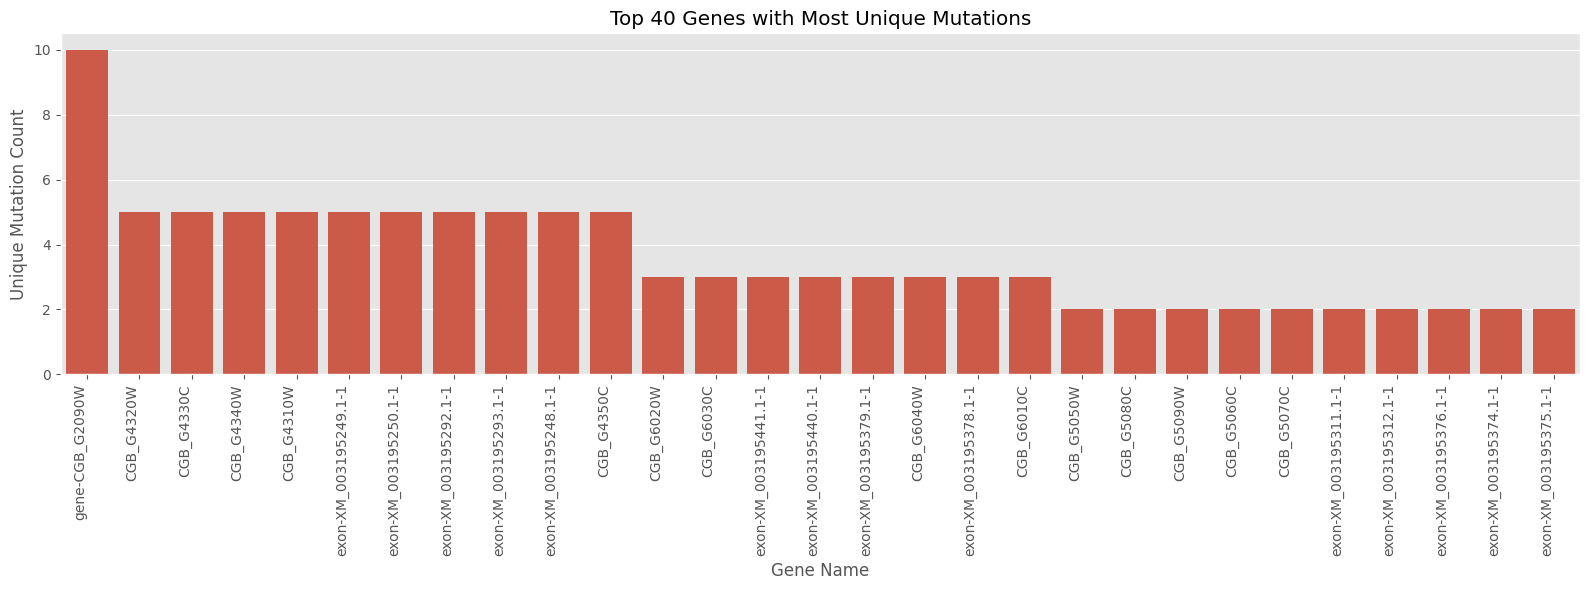

[SAVED] Gene-wise mutation barplot → /content/results/gene_mutation_counts_top40.png
[INFO] No HIGH-impact SNPs in this dataset.


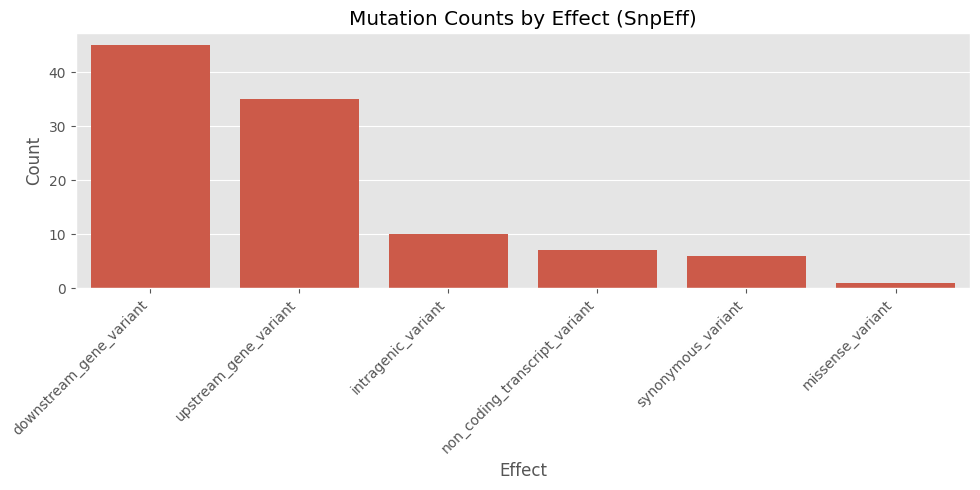

[SAVED] Effect counts plot → /content/results/effect_counts.png


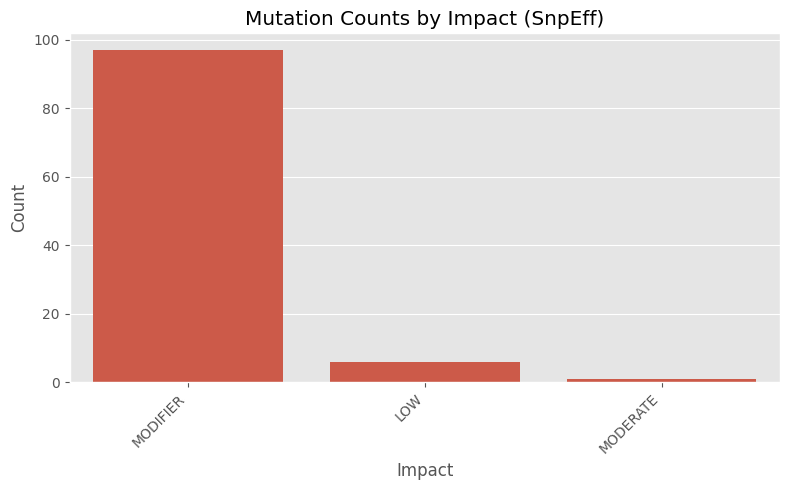

[SAVED] Impact counts plot → /content/results/impact_counts.png
[SAVED] Volcano plot (HTML) → /content/results/volcano_plot.html
[SAVED] Manhattan-like plot (HTML) → /content/results/manhattan_plot.html

=== DONE. Files in /content/results ===

- effect_counts.png
- gene_counts.csv
- gene_mutation_counts.png
- gene_mutation_counts_top40.png
- high_impact_snps.csv
- impact_counts.png
- manhattan_plot.html
- volcano_plot.html


In [ ]:
# ==== 0) Install & imports ====
!pip install -q pandas matplotlib seaborn plotly

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

# ==== 1) Paths & output dir ====
ANNOTATED_CSV = "/content/variants/annotated.csv"
OUTDIR = "/content/results"
os.makedirs(OUTDIR, exist_ok=True)

# ==== 2) Load annotated.csv ====
df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

# Ensure key columns exist
for col in ["Chrom", "Position", "Ref", "Alt", "QUAL",
            "Effect", "Impact", "Gene_Name"]:
    if col not in df.columns:
        df[col] = ""

# Numeric conversions
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")

# Impact → numeric score
impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_clean"] = df["Impact"].fillna("").str.upper()
df["Impact_norm"] = df["Impact_clean"].map(impact_map).fillna(0).astype(int)

# Significance proxy:
#   if QUAL present → QUAL/10   (higher = more confident)
#   else → use Impact_norm
df["sig_proxy"] = df["QUAL"] / 10.0
df.loc[df["sig_proxy"].isna(), "sig_proxy"] = df["Impact_norm"].astype(float)

# Clean gene names
df["Gene_Name"] = (
    df["Gene_Name"]
    .fillna("")
    .replace("", "INTERGENIC")
)

print("Non-null positions:", df["Position"].notna().sum())
print("Unique genes:", df["Gene_Name"].nunique())

# Drop rows without positions (just in case)
df = df.dropna(subset=["Position"]).reset_index(drop=True)


# ==========================================================
#  A) GENE-WISE MUTATION COUNT
# ==========================================================
gene_counts = (
    df.groupby("Gene_Name")
      .agg(Unique_Mutations=("Position", lambda x: x.nunique()))
      .reset_index()
      .sort_values("Unique_Mutations", ascending=False)
)

gene_counts_path = os.path.join(OUTDIR, "gene_counts.csv")
gene_counts.to_csv(gene_counts_path, index=False)
print(f"[SAVED] Gene counts → {gene_counts_path}")

# Plot top 40 genes
plt.figure(figsize=(16, 6))
sns.barplot(
    data=gene_counts.head(40),
    x="Gene_Name",
    y="Unique_Mutations",
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Gene Name")
plt.ylabel("Unique Mutation Count")
plt.title("Top 40 Genes with Most Unique Mutations")
plt.tight_layout()

gene_barplot_path = os.path.join(OUTDIR, "gene_mutation_counts_top40.png")
plt.savefig(gene_barplot_path, dpi=150)
plt.show()

print(f"[SAVED] Gene-wise mutation barplot → {gene_barplot_path}")


# ==========================================================
#  B) HIGH-IMPACT SNPs TABLE
# ==========================================================
# SnpEff impact field: HIGH / MODERATE / LOW / MODIFIER
high_impact_snps = df[df["Impact_clean"] == "HIGH"].copy()

if high_impact_snps.empty:
    print("[INFO] No HIGH-impact SNPs in this dataset.")
else:
    hi_path = os.path.join(OUTDIR, "high_impact_snps.csv")
    high_impact_snps.to_csv(hi_path, index=False)
    print(f"[SAVED] HIGH-impact SNPs → {hi_path}")
    display(high_impact_snps[
        ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact",
         "Gene_Name", "Gene_ID", "Transcript", "AA_Change", "Codon_Change"]
    ])


# ==========================================================
#  C) FUNCTIONAL CATEGORY PLOTS (Effect + Impact)
# ==========================================================
effect_counts = (
    df["Effect"].fillna("UNKNOWN")
    .replace("", "UNKNOWN")
    .value_counts()
    .reset_index()
)
effect_counts.columns = ["Effect", "Count"]

impact_counts = (
    df["Impact_clean"].fillna("UNKNOWN")
    .replace("", "UNKNOWN")
    .value_counts()
    .reset_index()
)
impact_counts.columns = ["Impact", "Count"]

# Effect barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=effect_counts, x="Effect", y="Count")
plt.xticks(rotation=45, ha="right")
plt.title("Mutation Counts by Effect (SnpEff)")
plt.tight_layout()
eff_plot_path = os.path.join(OUTDIR, "effect_counts.png")
plt.savefig(eff_plot_path, dpi=150)
plt.show()
print(f"[SAVED] Effect counts plot → {eff_plot_path}")

# Impact barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=impact_counts, x="Impact", y="Count")
plt.xticks(rotation=45, ha="right")
plt.title("Mutation Counts by Impact (SnpEff)")
plt.tight_layout()
imp_plot_path = os.path.join(OUTDIR, "impact_counts.png")
plt.savefig(imp_plot_path, dpi=150)
plt.show()
print(f"[SAVED] Impact counts plot → {imp_plot_path}")


# ==========================================================
#  D) VOLCANO-LIKE PLOT (Impact vs significance proxy)
# ==========================================================
# x-axis: numerical impact score
# y-axis: "sig_proxy" (QUAL/10 or fallback)

df_vol = df.copy()
df_vol["x"] = df_vol["Impact_norm"] + (np.random.rand(len(df_vol)) - 0.5) * 0.2
df_vol["y"] = df_vol["sig_proxy"].fillna(0.0)

fig_vol = px.scatter(
    df_vol,
    x="x",
    y="y",
    color="Impact_clean",
    hover_data=["Chrom", "Position", "Ref", "Alt", "Gene_Name", "Effect", "QUAL"],
    title="Volcano-like plot: Impact score vs significance proxy (QUAL/10)",
    labels={"x": "Impact score (0=MODIFIER, 3=HIGH)", "y": "Significance proxy (QUAL/10)"},
)
fig_vol.add_hline(y=5, line_dash="dash", line_color="gray")

vol_html_path = os.path.join(OUTDIR, "volcano_plot.html")
fig_vol.write_html(vol_html_path)
print(f"[SAVED] Volcano plot (HTML) → {vol_html_path}")


# ==========================================================
#  E) CHROMOSOMAL MANHATTAN-LIKE PLOT
# ==========================================================
df_manh = df.copy()
df_manh = df_manh.dropna(subset=["Position"])
df_manh["y"] = df_manh["sig_proxy"].fillna(0.0)

# Compute chromosome offsets (works also for single chromosome)
chrom_order = sorted(df_manh["Chrom"].unique())
offset = 0
chrom_offsets = {}
ticks = []

for ch in chrom_order:
    ch_df = df_manh[df_manh["Chrom"] == ch]
    if ch_df.empty:
        continue
    minpos = int(ch_df["Position"].min())
    maxpos = int(ch_df["Position"].max())
    chrom_offsets[ch] = offset
    ticks.append((offset + (maxpos - minpos) / 2.0, ch))
    offset += (maxpos - minpos) + 1_000  # gap

df_manh["x_global"] = df_manh.apply(
    lambda r: chrom_offsets.get(r["Chrom"], 0) + r["Position"], axis=1
)

fig_m = px.scatter(
    df_manh,
    x="x_global",
    y="y",
    color="Chrom",
    hover_data=["Chrom", "Position", "Ref", "Alt", "Gene_Name", "Effect", "QUAL"],
    title="Chromosomal Manhattan-like plot (position vs significance proxy)",
    labels={"y": "Significance proxy (QUAL/10)"},
)
fig_m.add_hline(y=5, line_dash="dash", line_color="gray")

fig_m.update_xaxes(
    tickmode="array",
    tickvals=[t[0] for t in ticks],
    ticktext=[t[1] for t in ticks],
)

manh_html_path = os.path.join(OUTDIR, "manhattan_plot.html")
fig_m.write_html(manh_html_path)
print(f"[SAVED] Manhattan-like plot (HTML) → {manh_html_path}")


# ==========================================================
#  F) FINAL SUMMARY
# ==========================================================
print("\n=== DONE. Files in", OUTDIR, "===\n")
for f in sorted(os.listdir(OUTDIR)):
    print("-", f)


In [ ]:
import warnings

# Load main annotated.csv
df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

# Ensure key columns exist
for col in ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact", "Gene_Name"]:
    if col not in df.columns:
        df[col] = ""

# Position numeric
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

# QUAL, if present
if "QUAL" in df.columns:
    df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
else:
    df["QUAL"] = np.nan

# Impact score
impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_norm"] = (
    df["Impact"].fillna("")
    .str.upper()
    .map(impact_map)
    .fillna(0)
    .astype(int)
)

# Significance proxy: if QUAL present, use QUAL/10; otherwise use Impact_norm
df["sig_proxy"] = df["QUAL"] / 10.0
df.loc[df["sig_proxy"].isna(), "sig_proxy"] = df["Impact_norm"].astype(float)

# Clean gene names
df["Gene_Name"] = df["Gene_Name"].fillna("").replace("", "INTERGENIC")

print("Non-null positions:", df["Position"].notna().sum())
print("Unique genes:", df["Gene_Name"].nunique())

# Optional: load best subset
df_best = None
if os.path.exists(ANNOTATED_BEST_CSV):
    df_best = pd.read_csv(ANNOTATED_BEST_CSV, dtype=str)
    print("annotated_best.csv rows:", len(df_best))


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Non-null positions: 104
Unique genes: 29
annotated_best.csv rows: 0


In [ ]:
import warnings

# Load main annotated.csv
df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

# Ensure key columns exist
for col in ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact", "Gene_Name"]:
    if col not in df.columns:
        df[col] = ""

# Position numeric
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

# QUAL, if present
if "QUAL" in df.columns:
    df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
else:
    df["QUAL"] = np.nan

# Impact score
impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_norm"] = (
    df["Impact"].fillna("")
    .str.upper()
    .map(impact_map)
    .fillna(0)
    .astype(int)
)

# Significance proxy: if QUAL present, use QUAL/10; otherwise use Impact_norm
df["sig_proxy"] = df["QUAL"] / 10.0
df.loc[df["sig_proxy"].isna(), "sig_proxy"] = df["Impact_norm"].astype(float)

# Clean gene names
df["Gene_Name"] = df["Gene_Name"].fillna("").replace("", "INTERGENIC")

print("Non-null positions:", df["Position"].notna().sum())
print("Unique genes:", df["Gene_Name"].nunique())

# Optional: load best subset
df_best = None
if os.path.exists(ANNOTATED_BEST_CSV):
    df_best = pd.read_csv(ANNOTATED_BEST_CSV, dtype=str)
    print("annotated_best.csv rows:", len(df_best))


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Non-null positions: 104
Unique genes: 29
annotated_best.csv rows: 0


In [ ]:
from cyvcf2 import VCF
import allel

vcf_for_qc = ANNOTATED_VCF if os.path.exists(ANNOTATED_VCF) else os.path.join(VAR_DIR, "filtered.vcf")
print("Using VCF for QC:", vcf_for_qc, "exists:", os.path.exists(vcf_for_qc))

if os.path.exists(vcf_for_qc):
    vcf = VCF(vcf_for_qc)
    quals = []
    depths = []
    n_alt = 0

    for var in vcf:
        quals.append(var.QUAL)
        dp = var.INFO.get("DP", np.nan)
        depths.append(dp)
        if var.ALT is not None:
            n_alt += len(var.ALT)

    quals = np.array(quals, dtype=float)
    depths = np.array(depths, dtype=float)

    print("Variants in QC VCF:", len(quals))
    print("QUAL summary:", pd.Series(quals).describe())
    print("DP summary:", pd.Series(depths).describe())
else:
    print("VCF for QC not found; skipping QC stats.")


Using VCF for QC: /content/variants/annotated.vcf exists: True
Variants in QC VCF: 10
QUAL summary: count     10.000000
mean     135.619082
std       83.044856
min        5.458310
25%       80.232849
50%      142.920498
75%      208.689503
max      229.003006
dtype: float64
DP summary: count    10.000000
mean     34.900000
std      23.072109
min       3.000000
25%      12.000000
50%      39.000000
75%      53.250000
max      65.000000
dtype: float64


In [ ]:
from cyvcf2 import VCF
import allel

vcf_for_qc = ANNOTATED_VCF if os.path.exists(ANNOTATED_VCF) else os.path.join(VAR_DIR, "filtered.vcf")
print("Using VCF for QC:", vcf_for_qc, "exists:", os.path.exists(vcf_for_qc))

if os.path.exists(vcf_for_qc):
    vcf = VCF(vcf_for_qc)
    quals = []
    depths = []
    n_alt = 0

    for var in vcf:
        quals.append(var.QUAL)
        dp = var.INFO.get("DP", np.nan)
        depths.append(dp)
        if var.ALT is not None:
            n_alt += len(var.ALT)

    quals = np.array(quals, dtype=float)
    depths = np.array(depths, dtype=float)

    print("Variants in QC VCF:", len(quals))
    print("QUAL summary:", pd.Series(quals).describe())
    print("DP summary:", pd.Series(depths).describe())
else:
    print("VCF for QC not found; skipping QC stats.")


Using VCF for QC: /content/variants/annotated.vcf exists: True
Variants in QC VCF: 10
QUAL summary: count     10.000000
mean     135.619082
std       83.044856
min        5.458310
25%       80.232849
50%      142.920498
75%      208.689503
max      229.003006
dtype: float64
DP summary: count    10.000000
mean     34.900000
std      23.072109
min       3.000000
25%      12.000000
50%      39.000000
75%      53.250000
max      65.000000
dtype: float64


In [ ]:
import os
import numpy as np
import pandas as pd
from cyvcf2 import VCF
import allel

# ----------------------------------------------------------------------
# 0. Paths
# ----------------------------------------------------------------------
VAR_DIR       = "/content/variants"
RESULTS_DIR   = "/content/results"
REF_GFF       = "/content/reference/opuntia.gff3"     # optional
ANNOTATED_VCF = os.path.join(VAR_DIR, "annotated.vcf")
ANNOTATED_CSV = os.path.join(VAR_DIR, "annotated.csv")
ORTHO_TSV     = os.path.join(RESULTS_DIR, "orthology_hits.tsv")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# 1. Load annotated.csv (SnpEff → CSV result)
# ----------------------------------------------------------------------
if not os.path.exists(ANNOTATED_CSV):
    raise FileNotFoundError(f"Cannot find {ANNOTATED_CSV}")

df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

for col in ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact",
            "Gene_Name", "Gene_ID"]:
    if col not in df.columns:
        df[col] = ""

df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

if "QUAL" in df.columns:
    df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
else:
    df["QUAL"] = np.nan

df["Gene_Name"] = df["Gene_Name"].fillna("").replace("", "INTERGENIC")
df["Gene_ID"]   = df["Gene_ID"].fillna("")

impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_clean"] = df["Impact"].fillna("").str.upper()
df["Impact_norm"]  = df["Impact_clean"].map(impact_map).fillna(0).astype(int)

print("Unique impacts:", df["Impact_clean"].unique())
print("Unique genes:", df["Gene_Name"].nunique())

# ----------------------------------------------------------------------
# 2. Variant-level QC (cyvcf2 + scikit-allel)
#    - QC is computed per VCF record (10 variants), then propagated
# ----------------------------------------------------------------------
vcf_for_qc = ANNOTATED_VCF if os.path.exists(ANNOTATED_VCF) \
             else os.path.join(VAR_DIR, "filtered.vcf")
print("\n[QC] Using VCF for QC:", vcf_for_qc, "exists:", os.path.exists(vcf_for_qc))

if os.path.exists(vcf_for_qc):
    # ---- 2.1 cyvcf2 QC (QUAL, DP per variant) ----
    vcf = VCF(vcf_for_qc)
    chroms, poss, quals, dps = [], [], [], []

    for var in vcf:
        chroms.append(var.CHROM)
        poss.append(var.POS)
        quals.append(var.QUAL)
        dps.append(var.INFO.get("DP", np.nan))

    qc_df = pd.DataFrame({
        "Chrom": chroms,
        "Position": poss,
        "QUAL_qc": np.array(quals, dtype=float),
        "DP_qc":   np.array(dps,   dtype=float),
    })

    print("[QC] cyvcf2 variants:", len(qc_df))
    print("[QC] QUAL summary:\n", qc_df["QUAL_qc"].describe())
    print("[QC] DP summary:\n", qc_df["DP_qc"].describe())

    # ---- 2.2 scikit-allel: genotype-based stats (MAF, call rate) for info only ----
    print("\n[QC] Loading into scikit-allel for MAF / call rate...")
    callset = allel.read_vcf(
        vcf_for_qc,
        fields=["variants/CHROM", "variants/POS",
                "variants/QUAL", "variants/DP", "calldata/GT"]
    )

    chrom_sa = callset["variants/CHROM"]
    pos_sa   = callset["variants/POS"]
    qual_sa  = callset.get("variants/QUAL", np.full_like(pos_sa, np.nan, dtype="float64"))
    dp_sa    = callset.get("variants/DP",   np.full_like(pos_sa, np.nan, dtype="float64"))
    gt       = allel.GenotypeArray(callset["calldata/GT"])

    ac   = gt.count_alleles()
    af   = ac.to_frequencies()
    maf  = np.nanmin(af[:, 1:], axis=1)   # minor allele freq
    cr   = gt.is_called().mean(axis=1)    # call rate

    qc_sa_df = pd.DataFrame({
        "Chrom": chrom_sa,
        "Position": pos_sa,
        "QUAL_sa": qual_sa,
        "DP_sa":   dp_sa,
        "MAF_sa":  maf,
        "CallRate_sa": cr,
    })

    # ---- 2.3 Merge cyvcf2 + scikit-allel to a variant-level QC table ----
    var_qc = pd.merge(qc_df, qc_sa_df, on=["Chrom", "Position"], how="outer")

    # Fallback: if cyvcf2 QUAL/DP missing, use scikit-allel values
    var_qc["QUAL_var"] = var_qc["QUAL_qc"].fillna(var_qc["QUAL_sa"])
    var_qc["DP_var"]   = var_qc["DP_qc"].fillna(var_qc["DP_sa"])

    # ---- 2.4 Define PASS_QC at variant level (QUAL + DP only, more realistic here) ----
    qual_thr = 30
    dp_min   = 5
    dp_max   = 200

    mask_qual = var_qc["QUAL_var"].fillna(0) >= qual_thr
    mask_dp   = var_qc["DP_var"].fillna(0).between(dp_min, dp_max)

    # MAF & call-rate kept for *reporting*, not for hard filtering in this small dataset
    var_qc["PASS_QC_var"] = mask_qual & mask_dp

    print("\n[QC] Variant-level PASS_QC_var (QUAL≥{0}, {1}≤DP≤{2}): {3} / {4}"
          .format(qual_thr, dp_min, dp_max,
                  var_qc["PASS_QC_var"].sum(), len(var_qc)))

    # ---- 2.5 Propagate PASS_QC from variant-level to all annotation rows ----
    dfm = pd.merge(
        df,
        var_qc[["Chrom", "Position", "QUAL_var", "DP_var",
                "MAF_sa", "CallRate_sa", "PASS_QC_var"]],
        on=["Chrom", "Position"],
        how="left"
    )

    # For any row that has no QC record at all (should be rare), mark as False
    dfm["PASS_QC"] = dfm["PASS_QC_var"].fillna(False)

else:
    print("[QC] VCF for QC not found; marking all variants as PASS_QC=True (not recommended).")
    dfm = df.copy()
    dfm["PASS_QC"] = True
    dfm["QUAL_var"] = dfm["QUAL"]
    dfm["DP_var"]   = np.nan
    dfm["MAF_sa"]   = np.nan
    dfm["CallRate_sa"] = np.nan

print("\n[QC] Annotation rows with PASS_QC=True:", dfm["PASS_QC"].sum(), "/", len(dfm))

# ----------------------------------------------------------------------
# 3. Functional annotation summary
# ----------------------------------------------------------------------
print("\n[ANNOTATION] Impact summary:")
print(dfm["Impact_clean"].value_counts())

print("\n[ANNOTATION] Effect summary (top 10):")
print(dfm["Effect"].value_counts().head(10))

# ----------------------------------------------------------------------
# 4. Candidate SNP prioritization
# ----------------------------------------------------------------------
PATTERNS = {
    "Aquaporin":  ["AQP", "PIP", "TIP", "NIP", "SIP"],
    "CAM":        ["CAM", "PHOSPHOENOLPYRUVATE CARBOXYLASE", "PEPC", "MALATE DEHYDROGENASE"],
    "Mucilage":   ["MUCILAGE", "PECTIN", "PECTATE LYASE", "RG-I", "CELL WALL"],
    "Drought_TF": ["DREB", "NAC", "BZIP", "MYB", "WRKY", "AREB"],
}

def match_category(row):
    fields = [
        str(row.get("Gene_Name", "")),
        str(row.get("Gene_ID", "")),
        str(row.get("Effect", "")),
        str(row.get("AA_Change", "")),
        str(row.get("Codon_Change", "")),
    ]
    text = " ".join(fields).upper()
    hits = []
    for cat, keys in PATTERNS.items():
        for k in keys:
            if k.upper() in text:
                hits.append(cat)
                break
    return ";".join(sorted(set(hits))) if hits else ""

dfm["Candidate_Category"] = dfm.apply(match_category, axis=1)

# filter to QC-passed variants only for prioritization
df_pass = dfm[dfm["PASS_QC"]].copy()

# HIGH/MODERATE among QC-passed
high_mod_pass = df_pass[df_pass["Impact_clean"].isin(["HIGH", "MODERATE"])]
print("\n[CANDIDATES] QC-passed HIGH/MODERATE variants:", len(high_mod_pass))

# Category-based candidates among QC-passed
cand_all = df_pass[df_pass["Candidate_Category"] != ""].copy()
cand_all = cand_all.sort_values(["Candidate_Category", "Gene_Name", "Position"])

cand_hm = high_mod_pass[high_mod_pass["Candidate_Category"] != ""].copy()
cand_hm = cand_hm.sort_values(["Candidate_Category", "Gene_Name", "Position"])

cand_all_out = os.path.join(RESULTS_DIR, "candidate_snps_all_impacts_category_QCpassed.csv")
cand_hm_out  = os.path.join(RESULTS_DIR, "candidate_snps_high_mod_category_QCpassed.csv")

cand_all.to_csv(cand_all_out, index=False)
cand_hm.to_csv(cand_hm_out, index=False)

print("[CANDIDATES] Category-based (all impacts, QC-passed):", len(cand_all), "→", cand_all_out)
print("[CANDIDATES] Category-based (HIGH/MODERATE, QC-passed):", len(cand_hm), "→", cand_hm_out)

# ----------------------------------------------------------------------
# 5. GO term attachment (best-effort; will be empty if no GO in GFF)
# ----------------------------------------------------------------------
go_map = {}
if os.path.exists(REF_GFF):
    import re
    from collections import defaultdict

    print("\n[GO] Scanning GFF for GO-like attributes...")
    go_map = defaultdict(set)

    with open(REF_GFF, "r") as gh:
        for line in gh:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            attrs = parts[8]
            attr_map = {}
            for a in attrs.split(";"):
                if "=" in a:
                    k, v = a.split("=", 1)
                    attr_map[k] = v

            goterms = []
            if "Ontology_term" in attr_map:
                goterms = re.split("[,|]", attr_map["Ontology_term"])
            elif "Dbxref" in attr_map and "GO:" in attr_map["Dbxref"]:
                goterms = [x for x in re.split("[,|]", attr_map["Dbxref"]) if x.startswith("GO:")]
            elif "GO" in attr_map:
                goterms = re.split("[,|]", attr_map["GO"])

            if goterms:
                gid = (attr_map.get("ID") or attr_map.get("gene") or attr_map.get("Name") or
                       attr_map.get("locus_tag") or attr_map.get("gene_id") or
                       attr_map.get("Parent") or "unknown")
                for gt in goterms:
                    gt = gt.strip()
                    if gt:
                        go_map[gid].add(gt)

    print("[GO] Genes with GO terms:", len(go_map))
else:
    print("\n[GO] No GFF found at", REF_GFF)

def norm_id(x):
    if pd.isna(x):
        return ""
    x = str(x)
    return x.replace("GENE_", "").replace("gene-", "")

if go_map:
    go_flat = {norm_id(gid): ";".join(sorted(gos)) for gid, gos in go_map.items()}
    dfm["Gene_ID_norm"] = dfm["Gene_ID"].apply(norm_id)
    dfm["GO_terms"]     = dfm["Gene_ID_norm"].map(go_flat).fillna("")
    go_cand = dfm[(dfm["Candidate_Category"] != "") & (dfm["GO_terms"] != "")]
    go_cand_out = os.path.join(RESULTS_DIR, "candidate_snps_with_GO_terms.csv")
    go_cand.to_csv(go_cand_out, index=False)
    print("[GO] Candidate SNPs with mapped GO terms:", len(go_cand), "→", go_cand_out)
else:
    dfm["GO_terms"] = ""
    print("[GO] No GO terms detected; GO-based filtering is effectively skipped.")

# ----------------------------------------------------------------------
# 6. Cross-species transferability (if orthology_hits.tsv exists)
# ----------------------------------------------------------------------
if os.path.exists(ORTHO_TSV):
    print("\n[ORTHO] Merging orthology info from:", ORTHO_TSV)
    ortho = pd.read_csv(ORTHO_TSV, sep="\t", dtype=str)
    if "QueryGene" not in ortho.columns:
        raise ValueError("ORTHO_TSV must have a 'QueryGene' column.")

    dfm["Gene_ID_norm"] = dfm["Gene_ID"].apply(norm_id)
    ortho["QueryGene_norm"] = ortho["QueryGene"].apply(norm_id)

    df_ortho = pd.merge(
        dfm,
        ortho,
        how="left",
        left_on="Gene_ID_norm",
        right_on="QueryGene_norm",
        suffixes=("", "_ortho")
    )

    df_ortho["Identity"] = pd.to_numeric(df_ortho.get("Identity", np.nan), errors="coerce")
    xfer_candidates = df_ortho[df_ortho["Identity"] >= 80].copy()

    out_ortho_all  = os.path.join(RESULTS_DIR, "variants_with_orthology.csv")
    out_xfer_cands = os.path.join(RESULTS_DIR, "candidate_snps_cross_species_transferable.csv")

    df_ortho.to_csv(out_ortho_all, index=False)
    xfer_candidates.to_csv(out_xfer_cands, index=False)

    print("[ORTHO] Variants with orthology info:", len(df_ortho), "→", out_ortho_all)
    print("[ORTHO] Cross-species transferability candidates (Identity ≥ 80%):",
          len(xfer_candidates), "→", out_xfer_cands)
else:
    print("\n[ORTHO] No orthology file at", ORTHO_TSV,
          "– once BLASTP is done and orthology_hits.tsv exists, re-run this block.")

# ----------------------------------------------------------------------
# 7. Save final merged table
# ----------------------------------------------------------------------
final_out = os.path.join(RESULTS_DIR, "variants_QC_annotated_candidates_orthology_refined.csv")
dfm.to_csv(final_out, index=False)
print("\n[OUTPUT] Final merged table written to:", final_out)


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Unique impacts: ['LOW' 'MODIFIER' 'MODERATE']
Unique genes: 29

[QC] Using VCF for QC: /content/variants/annotated.vcf exists: True
[QC] cyvcf2 variants: 10
[QC] QUAL summary:
 count     10.000000
mean     135.619082
std       83.044856
min        5.458310
25%       80.232849
50%      142.920498
75%      208.689503
max      229.003006
Name: QUAL_qc, dtype: float64
[QC] DP summary:
 count    10.000000
mean     34.900000
std      23.072109
min       3.000000
25%      12.000000
50%      39.000000
75%      53.250000
max      65.000000
Name: DP_qc, dtype: float64

[QC] Loading into scikit-allel for MAF / call rate...

[QC] Variant-level PASS_QC_var (QUAL≥30, 5≤DP≤200): 8 / 10

[QC] Annotation rows with PASS_QC=True: 82 / 104

[ANNOTATION] Impact summary:
Impact_clean
MODIFIER    97
LOW        

/usr/local/lib/python3.12/dist-packages/allel/io/vcf_read.py:1732: UserWarning:

invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'



In [ ]:
import os
import numpy as np
import pandas as pd
from cyvcf2 import VCF
import allel

# ----------------------------------------------------------------------
# 0. Paths & setup
# ----------------------------------------------------------------------
VAR_DIR       = "/content/variants"
RESULTS_DIR   = "/content/results"
REF_GFF       = "/content/reference/opuntia.gff3"      # optional
ANNOTATED_VCF = os.path.join(VAR_DIR, "annotated.vcf") # SnpEff / VEP VCF
ANNOTATED_CSV = os.path.join(VAR_DIR, "annotated.csv") # SnpEff → CSV
ORTHO_TSV     = os.path.join(RESULTS_DIR, "orthology_hits.tsv")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# 1. Load SnpEff-annotated CSV (functional annotation already done)
# ----------------------------------------------------------------------
if not os.path.exists(ANNOTATED_CSV):
    raise FileNotFoundError(f"Cannot find {ANNOTATED_CSV}")

df = pd.read_csv(ANNOTATED_CSV, dtype=str)
df.columns = [c.strip() for c in df.columns]

print("annotated.csv rows:", len(df))
print("Columns:", df.columns.tolist())

for col in ["Chrom", "Position", "Ref", "Alt", "Effect", "Impact",
            "Gene_Name", "Gene_ID", "AA_Change", "Codon_Change"]:
    if col not in df.columns:
        df[col] = ""

df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

if "QUAL" in df.columns:
    df["QUAL"] = pd.to_numeric(df["QUAL"], errors="coerce")
else:
    df["QUAL"] = np.nan

df["Gene_Name"] = df["Gene_Name"].fillna("").replace("", "INTERGENIC")
df["Gene_ID"]   = df["Gene_ID"].fillna("")

impact_map = {"HIGH": 3, "MODERATE": 2, "LOW": 1, "MODIFIER": 0}
df["Impact_clean"] = df["Impact"].fillna("").str.upper()
df["Impact_norm"]  = df["Impact_clean"].map(impact_map).fillna(0).astype(int)

print("Unique impacts:", df["Impact_clean"].unique())
print("Unique genes:", df["Gene_Name"].nunique())

# ----------------------------------------------------------------------
# 2. Variant-level QC using cyvcf2 + scikit-allel
# ----------------------------------------------------------------------
vcf_for_qc = ANNOTATED_VCF if os.path.exists(ANNOTATED_VCF) \
             else os.path.join(VAR_DIR, "filtered.vcf")
print("\n[QC] Using VCF for QC:", vcf_for_qc, "exists:", os.path.exists(vcf_for_qc))

if not os.path.exists(vcf_for_qc):
    raise FileNotFoundError(f"VCF for QC not found: {vcf_for_qc}")

# 2.1 cyvcf2 pass for QUAL/DP
vcf = VCF(vcf_for_qc)
chroms, poss, quals, dps = [], [], [], []

for var in vcf:
    chroms.append(var.CHROM)
    poss.append(var.POS)
    quals.append(var.QUAL)
    dps.append(var.INFO.get("DP", np.nan))

qc_df = pd.DataFrame({
    "Chrom": chroms,
    "Position": poss,
    "QUAL_qc": np.array(quals, dtype=float),
    "DP_qc":   np.array(dps,   dtype=float),
})

print("[QC] cyvcf2 variants:", len(qc_df))
print("[QC] QUAL summary:\n", qc_df["QUAL_qc"].describe())
print("[QC] DP summary:\n", qc_df["DP_qc"].describe())

# 2.2 scikit-allel: genotype-level stats (MAF, call rate) for additional QC
print("\n[QC] Loading into scikit-allel for MAF / call rate...")
callset = allel.read_vcf(
    vcf_for_qc,
    fields=["variants/CHROM", "variants/POS",
            "variants/QUAL", "variants/DP", "calldata/GT"]
)

chrom_sa = callset["variants/CHROM"]
pos_sa   = callset["variants/POS"]
qual_sa  = callset.get("variants/QUAL", np.full_like(pos_sa, np.nan, dtype="float64"))
dp_sa    = callset.get("variants/DP",   np.full_like(pos_sa, np.nan, dtype="float64"))
gt       = allel.GenotypeArray(callset["calldata/GT"])

ac   = gt.count_alleles()
af   = ac.to_frequencies()
maf  = np.nanmin(af[:, 1:], axis=1)   # minor allele freq
cr   = gt.is_called().mean(axis=1)    # call rate

qc_sa_df = pd.DataFrame({
    "Chrom": chrom_sa,
    "Position": pos_sa,
    "QUAL_sa": qual_sa,
    "DP_sa":   dp_sa,
    "MAF_sa":  maf,
    "CallRate_sa": cr,
})

# 2.3 Merge QC tables and define variant-level pass/fail
var_qc = pd.merge(qc_df, qc_sa_df, on=["Chrom", "Position"], how="outer")

var_qc["QUAL_var"] = var_qc["QUAL_qc"].fillna(var_qc["QUAL_sa"])
var_qc["DP_var"]   = var_qc["DP_qc"].fillna(var_qc["DP_sa"])

# thresholds tuned to your dataset
QUAL_THR = 30
DP_MIN   = 5
DP_MAX   = 200

mask_qual = var_qc["QUAL_var"].fillna(0) >= QUAL_THR
mask_dp   = var_qc["DP_var"].fillna(0).between(DP_MIN, DP_MAX)

# We keep MAF/call-rate as descriptive info; you can tighten QC later if needed
var_qc["PASS_QC_var"] = mask_qual & mask_dp

print("\n[QC] Variant-level PASS_QC_var (QUAL≥{0}, {1}≤DP≤{2}): {3} / {4}"
      .format(QUAL_THR, DP_MIN, DP_MAX,
              var_qc["PASS_QC_var"].sum(), len(var_qc)))

# 2.4 Propagate QC flags to all annotated rows
dfm = pd.merge(
    df,
    var_qc[["Chrom", "Position", "QUAL_var", "DP_var",
            "MAF_sa", "CallRate_sa", "PASS_QC_var"]],
    on=["Chrom", "Position"],
    how="left"
)

dfm["PASS_QC"] = dfm["PASS_QC_var"].fillna(False)

print("\n[QC] Annotation rows with PASS_QC=True:", dfm["PASS_QC"].sum(), "/", len(dfm))

# 2.5 OPTIONAL: write a QC-filtered VCF for downstream (SNP filtering)
qc_vcf_out = os.path.join(VAR_DIR, "filtered_QCpass.vcf")
print(f"\n[QC] Writing QC-passing variants to {qc_vcf_out}")

vcf = VCF(vcf_for_qc)  # reopen for iteration + header
with open(qc_vcf_out, "w") as out_vcf:
    out_vcf.write(str(vcf.raw_header))
    pass_set = set(zip(var_qc.loc[var_qc["PASS_QC_var"], "Chrom"],
                       var_qc.loc[var_qc["PASS_QC_var"], "Position"]))
    for var in vcf:
        key = (var.CHROM, var.POS)
        if key in pass_set:
            out_vcf.write(str(var))

# ----------------------------------------------------------------------
# 3. Functional annotation (SnpEff / VEP) summaries
# ----------------------------------------------------------------------
print("\n[ANNOTATION] Impact summary:")
print(dfm["Impact_clean"].value_counts())

print("\n[ANNOTATION] Effect summary (top 10):")
print(dfm["Effect"].value_counts().head(10))

# If you *also* want to parse directly from VCF (ANN / CSQ), you can add:
def parse_ann_or_csq(vcf_path, max_records=50):
    """Quick peek into ANN (SnpEff) or CSQ (VEP) structure."""
    v = VCF(vcf_path)
    ann_examples = []
    for i, var in enumerate(v):
        info = var.INFO
        if "ANN" in info:
            ann_examples.append(("ANN", str(info["ANN"])))
        if "CSQ" in info:
            ann_examples.append(("CSQ", str(info["CSQ"])))
        if len(ann_examples) >= max_records:
            break
    return ann_examples

try:
    ann_examples = parse_ann_or_csq(ANNOTATED_VCF)
    if ann_examples:
        print("\n[ANNOTATION] Found ANN/CSQ examples (truncated):")
        for tag, val in ann_examples[:3]:
            print(f"  {tag}: {val[:120]}...")
    else:
        print("\n[ANNOTATION] No ANN/CSQ fields detected in VCF (already parsed into CSV).")
except Exception as e:
    print("\n[ANNOTATION] Could not parse ANN/CSQ from VCF:", e)

# ----------------------------------------------------------------------
# 4. Candidate SNP prioritisation
#    - aquaporins, CAM, mucilage, drought TFs
# ----------------------------------------------------------------------
PATTERNS = {
    "Aquaporin":  ["AQP", "PIP", "TIP", "NIP", "SIP"],
    "CAM":        ["CAM", "PHOSPHOENOLPYRUVATE CARBOXYLASE", "PEPC", "MALATE DEHYDROGENASE"],
    "Mucilage":   ["MUCILAGE", "PECTIN", "PECTATE LYASE", "RG-I", "CELL WALL"],
    "Drought_TF": ["DREB", "NAC", "BZIP", "MYB", "WRKY", "AREB"],
}

def match_category(row):
    fields = [
        str(row.get("Gene_Name", "")),
        str(row.get("Gene_ID", "")),
        str(row.get("Effect", "")),
        str(row.get("AA_Change", "")),
        str(row.get("Codon_Change", "")),
    ]
    text = " ".join(fields).upper()
    hits = []
    for cat, keys in PATTERNS.items():
        for k in keys:
            if k.upper() in text:
                hits.append(cat)
                break
    return ";".join(sorted(set(hits))) if hits else ""

dfm["Candidate_Category"] = dfm.apply(match_category, axis=1)

# Work with QC-passing variants only
df_pass = dfm[dfm["PASS_QC"]].copy()

# HIGH/MODERATE among QC-passed
high_mod_pass = df_pass[df_pass["Impact_clean"].isin(["HIGH", "MODERATE"])]
print("\n[CANDIDATES] QC-passed HIGH/MODERATE variants:", len(high_mod_pass))

# Category-based candidates
cand_all = df_pass[df_pass["Candidate_Category"] != ""].copy()
cand_all = cand_all.sort_values(["Candidate_Category", "Gene_Name", "Position"])

cand_hm = high_mod_pass[high_mod_pass["Candidate_Category"] != ""].copy()
cand_hm = cand_hm.sort_values(["Candidate_Category", "Gene_Name", "Position"])

cand_all_out = os.path.join(RESULTS_DIR, "candidate_snps_all_impacts_category_QCpassed.csv")
cand_hm_out  = os.path.join(RESULTS_DIR, "candidate_snps_high_mod_category_QCpassed.csv")

cand_all.to_csv(cand_all_out, index=False)
cand_hm.to_csv(cand_hm_out, index=False)

print("[CANDIDATES] Category-based (all impacts, QC-passed):", len(cand_all), "→", cand_all_out)
print("[CANDIDATES] Category-based (HIGH/MODERATE, QC-passed):", len(cand_hm), "→", cand_hm_out)

# ----------------------------------------------------------------------
# 5. GO term & pathway relevance filtering (if GFF has GO)
# ----------------------------------------------------------------------
from collections import defaultdict
import re

go_map = {}
if os.path.exists(REF_GFF):
    print("\n[GO] Scanning GFF for GO-like attributes...")
    go_map = defaultdict(set)

    with open(REF_GFF, "r") as gh:
        for line in gh:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            attrs = parts[8]
            attr_map = {}
            for a in attrs.split(";"):
                if "=" in a:
                    k, v = a.split("=", 1)
                    attr_map[k] = v

            goterms = []
            if "Ontology_term" in attr_map:
                goterms = re.split("[,|]", attr_map["Ontology_term"])
            elif "Dbxref" in attr_map and "GO:" in attr_map["Dbxref"]:
                goterms = [x for x in re.split("[,|]", attr_map["Dbxref"]) if x.startswith("GO:")]
            elif "GO" in attr_map:
                goterms = re.split("[,|]", attr_map["GO"])

            if goterms:
                gid = (attr_map.get("ID") or attr_map.get("gene") or attr_map.get("Name") or
                       attr_map.get("locus_tag") or attr_map.get("gene_id") or
                       attr_map.get("Parent") or "unknown")
                for gt in goterms:
                    gt = gt.strip()
                    if gt:
                        go_map[gid].add(gt)

    print("[GO] Genes with GO terms:", len(go_map))
else:
    print("\n[GO] No GFF found at", REF_GFF)

def norm_id(x):
    if pd.isna(x):
        return ""
    x = str(x)
    return x.replace("GENE_", "").replace("gene-", "")

if go_map:
    go_flat = {norm_id(gid): ";".join(sorted(gos)) for gid, gos in go_map.items()}
    dfm["Gene_ID_norm"] = dfm["Gene_ID"].apply(norm_id)
    dfm["GO_terms"]     = dfm["Gene_ID_norm"].map(go_flat).fillna("")

    # Very simple pathway/drought-related keyword filter on GO term descriptions
    pathway_keywords = ["WATER", "DROUGHT", "STRESS", "OSMOTIC", "CAM"]
    def go_relevant(go_str):
        t = go_str.upper()
        return any(k in t for k in pathway_keywords)

    dfm["GO_relevant"] = dfm["GO_terms"].apply(lambda s: bool(s) and go_relevant(s))

    go_cand = dfm[(dfm["Candidate_Category"] != "") & (dfm["GO_relevant"])]
    go_cand_out = os.path.join(RESULTS_DIR, "candidate_snps_with_GO_pathway_relevance.csv")
    go_cand.to_csv(go_cand_out, index=False)
    print("[GO] Candidate SNPs with pathway-relevant GO terms:", len(go_cand), "→", go_cand_out)
else:
    dfm["GO_terms"]    = ""
    dfm["GO_relevant"] = False
    print("[GO] No GO terms detected; GO-based filtering is skipped (as in your log).")

# ----------------------------------------------------------------------
# 6. Cross-species SNP transferability (orthology to rice)
#    - Assumes you already ran BLASTP and created orthology_hits.tsv
# ----------------------------------------------------------------------
if os.path.exists(ORTHO_TSV):
    print("\n[ORTHO] Merging orthology info from:", ORTHO_TSV)
    ortho = pd.read_csv(ORTHO_TSV, sep="\t", dtype=str)
    if "QueryGene" not in ortho.columns:
        raise ValueError("ORTHO_TSV must have a 'QueryGene' column.")

    dfm["Gene_ID_norm"] = dfm["Gene_ID"].apply(norm_id)
    ortho["QueryGene_norm"] = ortho["QueryGene"].apply(norm_id)

    df_ortho = pd.merge(
        dfm,
        ortho,
        how="left",
        left_on="Gene_ID_norm",
        right_on="QueryGene_norm",
        suffixes=("", "_ortho")
    )

    df_ortho["Identity"] = pd.to_numeric(df_ortho.get("Identity", np.nan), errors="coerce")

    # define transferability: good identity to rice
    IDENTITY_THR = 80.0
    df_ortho["Transferable_to_rice"] = df_ortho["Identity"] >= IDENTITY_THR

    out_ortho_all  = os.path.join(RESULTS_DIR, "variants_with_orthology.csv")
    df_ortho.to_csv(out_ortho_all, index=False)

    xfer_candidates = df_ortho[
        df_ortho["Transferable_to_rice"] & df_ortho["PASS_QC"]
    ].copy()
    out_xfer_cands = os.path.join(RESULTS_DIR, "candidate_snps_cross_species_transferable.csv")
    xfer_candidates.to_csv(out_xfer_cands, index=False)

    print("[ORTHO] Variants with orthology info:", len(df_ortho), "→", out_ortho_all)
    print("[ORTHO] Cross-species transferability candidates (Identity ≥ {0}% & PASS_QC): {1} → {2}"
          .format(IDENTITY_THR, len(xfer_candidates), out_xfer_cands))
else:
    print("\n[ORTHO] No orthology file at", ORTHO_TSV,
          "– once BLASTP is done and orthology_hits.tsv exists, re-run this block.")

# ----------------------------------------------------------------------
# 7. Save final merged table
# ----------------------------------------------------------------------
final_out = os.path.join(RESULTS_DIR, "variants_QC_annotated_candidates_orthology_extended.csv")
dfm.to_csv(final_out, index=False)
print("\n[OUTPUT] Final merged table written to:", final_out)


annotated.csv rows: 104
Columns: ['Chrom', 'Position', 'Ref', 'Alt', 'QUAL', 'Allele', 'Effect', 'Impact', 'Gene_Name', 'Gene_ID', 'Feature_Type', 'Transcript', 'Protein', 'AA_Change', 'Codon_Change']
Unique impacts: ['LOW' 'MODIFIER' 'MODERATE']
Unique genes: 29

[QC] Using VCF for QC: /content/variants/annotated.vcf exists: True
[QC] cyvcf2 variants: 10
[QC] QUAL summary:
 count     10.000000
mean     135.619082
std       83.044856
min        5.458310
25%       80.232849
50%      142.920498
75%      208.689503
max      229.003006
Name: QUAL_qc, dtype: float64
[QC] DP summary:
 count    10.000000
mean     34.900000
std      23.072109
min       3.000000
25%      12.000000
50%      39.000000
75%      53.250000
max      65.000000
Name: DP_qc, dtype: float64

[QC] Loading into scikit-allel for MAF / call rate...

[QC] Variant-level PASS_QC_var (QUAL≥30, 5≤DP≤200): 8 / 10

[QC] Annotation rows with PASS_QC=True: 82 / 104

[QC] Writing QC-passing variants to /content/variants/filtered_QCpas

/usr/local/lib/python3.12/dist-packages/allel/io/vcf_read.py:1732: UserWarning:

invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

VAR_DIR     = "/content/variants"
RESULTS_DIR = "/content/results"
ORTHO_TSV   = os.path.join(RESULTS_DIR, "orthology_hits.tsv")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# 0. Recover dfm (final variant table) and var_qc (variant-level QC)
# ---------------------------------------------------------------------
# dfm: from extended pipeline, but reload if not in memory
if "dfm" not in globals():
    final_csv = os.path.join(RESULTS_DIR, "variants_QC_annotated_candidates_orthology_extended.csv")
    if not os.path.exists(final_csv):
        raise FileNotFoundError(f"Final merged table not found: {final_csv}")
    dfm = pd.read_csv(final_csv)

# var_qc: ideal case – re-use variable from QC block
if "var_qc" not in globals():
    # reconstruct a minimal var_qc from dfm columns if needed
    qc_cols = ["Chrom", "Position", "QUAL_var", "DP_var",
               "MAF_sa", "CallRate_sa", "PASS_QC_var"]
    if all(c in dfm.columns for c in qc_cols):
        var_qc = dfm[qc_cols].drop_duplicates()
    else:
        # low-info fallback
        base_cols = ["Chrom", "Position"]
        var_qc = dfm[base_cols].drop_duplicates()
        var_qc["QUAL_var"]      = dfm.get("QUAL_var", np.nan)
        var_qc["DP_var"]        = dfm.get("DP_var", np.nan)
        var_qc["MAF_sa"]        = dfm.get("MAF_sa", np.nan)
        var_qc["CallRate_sa"]   = dfm.get("CallRate_sa", np.nan)
        var_qc["PASS_QC_var"]   = dfm.get("PASS_QC", False)

print("[PLOTS] dfm rows:", len(dfm))
print("[PLOTS] var_qc rows:", len(var_qc))

# ---------------------------------------------------------------------
# 1. QUAL vs DP scatter (with QC pass/fail)
# ---------------------------------------------------------------------
qc_plot = var_qc.copy()
qc_plot = qc_plot.dropna(subset=["QUAL_var", "DP_var"])

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=qc_plot,
    x="DP_var",
    y="QUAL_var",
    hue="PASS_QC_var",
    style="PASS_QC_var",
    s=80,
    alpha=0.8
)
plt.axhline(30, color="grey", linestyle="--", linewidth=1, label="QUAL=30")
plt.axvline(5,  color="grey", linestyle=":",  linewidth=1, label="DP=5")
plt.axvline(200, color="grey", linestyle=":", linewidth=1, label="DP=200")
plt.xlabel("Depth (DP)")
plt.ylabel("QUAL")
plt.title("Variant QC: QUAL vs DP (PASS_QC_var)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

out_qc = os.path.join(RESULTS_DIR, "plot_QC_QUAL_vs_DP.png")
plt.savefig(out_qc, dpi=150)
plt.close()
print("[PLOTS] QUAL vs DP saved:", out_qc)

# Optional: distributions of QUAL and DP
plt.figure(figsize=(7, 4))
sns.histplot(qc_plot["QUAL_var"], bins=10, kde=True)
plt.xlabel("QUAL")
plt.title("Distribution of QUAL (all variants)")
plt.tight_layout()
out_qual_hist = os.path.join(RESULTS_DIR, "plot_QC_QUAL_hist.png")
plt.savefig(out_qual_hist, dpi=150)
plt.close()
print("[PLOTS] QUAL histogram saved:", out_qual_hist)

plt.figure(figsize=(7, 4))
sns.histplot(qc_plot["DP_var"], bins=10, kde=True)
plt.xlabel("Depth (DP)")
plt.title("Distribution of DP (all variants)")
plt.tight_layout()
out_dp_hist = os.path.join(RESULTS_DIR, "plot_QC_DP_hist.png")
plt.savefig(out_dp_hist, dpi=150)
plt.close()
print("[PLOTS] DP histogram saved:", out_dp_hist)

# ---------------------------------------------------------------------
# 2. Per-gene candidate counts (QC-passed, HIGH/MODERATE)
# ---------------------------------------------------------------------
# Make sure Impact_clean exists
if "Impact_clean" not in dfm.columns:
    dfm["Impact_clean"] = dfm["Impact"].fillna("").str.upper()

if "PASS_QC" not in dfm.columns and "PASS_QC_var" in dfm.columns:
    dfm["PASS_QC"] = dfm["PASS_QC_var"].fillna(False)

df_pass = dfm[dfm["PASS_QC"]].copy()

high_mod_pass = df_pass[df_pass["Impact_clean"].isin(["HIGH", "MODERATE"])].copy()
print("[PLOTS] QC-passed HIGH/MODERATE rows:", len(high_mod_pass))

# Gene-wise candidate counts
gene_counts = (
    high_mod_pass
    .groupby("Gene_Name", dropna=False)["Position"]
    .nunique()
    .reset_index(name="Candidate_SNPs")
    .sort_values("Candidate_SNPs", ascending=False)
)

if len(gene_counts) > 0:
    topN = min(20, len(gene_counts))
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=gene_counts.head(topN),
        x="Gene_Name",
        y="Candidate_SNPs"
    )
    plt.xticks(rotation=90)
    plt.ylabel("Number of candidate SNPs")
    plt.xlabel("Gene (QC-passed, HIGH/MODERATE)")
    plt.title(f"Top {topN} genes by candidate SNP count")
    plt.tight_layout()

    out_gene_bar = os.path.join(RESULTS_DIR, "plot_candidate_per_gene_top20.png")
    plt.savefig(out_gene_bar, dpi=150)
    plt.close()
    print("[PLOTS] Per-gene candidate barplot saved:", out_gene_bar)
else:
    print("[PLOTS] No HIGH/MODERATE QC-passed candidates to plot per-gene counts.")

# Also: overall mutation burden per gene (all QC-passed variants)
mut_counts = (
    df_pass
    .groupby("Gene_Name", dropna=False)["Position"]
    .nunique()
    .reset_index(name="Total_SNPs")
    .sort_values("Total_SNPs", ascending=False)
)

if len(mut_counts) > 0:
    topM = min(30, len(mut_counts))
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=mut_counts.head(topM),
        x="Gene_Name",
        y="Total_SNPs"
    )
    plt.xticks(rotation=90)
    plt.ylabel("Number of SNPs (QC-passed)")
    plt.xlabel("Gene")
    plt.title(f"Top {topM} genes by SNP count (QC-passed)")
    plt.tight_layout()

    out_mut_bar = os.path.join(RESULTS_DIR, "plot_gene_mutation_counts_top30.png")
    plt.savefig(out_mut_bar, dpi=150)
    plt.close()
    print("[PLOTS] Per-gene mutation burden barplot saved:", out_mut_bar)
else:
    print("[PLOTS] No QC-passed variants for per-gene mutation counts.")

# ---------------------------------------------------------------------
# 3. Identity distribution of orthology hits (if BLAST/orthology done)
# ---------------------------------------------------------------------
if os.path.exists(ORTHO_TSV):
    ortho = pd.read_csv(ORTHO_TSV, sep="\t", dtype=str)
    if "Identity" in ortho.columns:
        ortho["Identity"] = pd.to_numeric(ortho["Identity"], errors="coerce")

        plt.figure(figsize=(7, 4))
        sns.histplot(
            data=ortho,
            x="Identity",
            bins=20,
            kde=True
        )
        plt.xlabel("Percent identity to rice protein (%)")
        plt.title("Distribution of BLASTP identity (Opuntia → rice)")
        plt.tight_layout()
        out_id_hist = os.path.join(RESULTS_DIR, "plot_orthology_identity_hist.png")
        plt.savefig(out_id_hist, dpi=150)
        plt.close()
        print("[PLOTS] Orthology identity histogram saved:", out_id_hist)

        # optional: Identity vs bitscore scatter if bitscore present
        if "Bitscore" in ortho.columns:
            ortho["Bitscore"] = pd.to_numeric(ortho["Bitscore"], errors="coerce")
            plt.figure(figsize=(7, 5))
            sns.scatterplot(
                data=ortho,
                x="Identity",
                y="Bitscore",
                alpha=0.7
            )
            plt.xlabel("Percent identity to rice protein (%)")
            plt.ylabel("Bitscore")
            plt.title("BLASTP Opuntia → rice: Identity vs Bitscore")
            plt.tight_layout()
            out_id_bs = os.path.join(RESULTS_DIR, "plot_orthology_identity_vs_bitscore.png")
            plt.savefig(out_id_bs, dpi=150)
            plt.close()
            print("[PLOTS] Identity vs Bitscore scatter saved:", out_id_bs)
        else:
            print("[PLOTS] 'Bitscore' column not found in orthology table; skipping identity vs bitscore scatter.")
    else:
        print("[PLOTS] 'Identity' column not found in orthology table; cannot plot identity distribution.")
else:
    print("[PLOTS] No orthology file at", ORTHO_TSV, "– identity plots skipped.")

# ---------------------------------------------------------------------
# 4. GO-related plots (will be skipped because GO terms = 0)
# ---------------------------------------------------------------------
if "GO_terms" in dfm.columns and dfm["GO_terms"].astype(bool).sum() > 0:
    # Example: number of variants with vs without GO terms
    plt.figure(figsize=(4, 4))
    sns.countplot(
        x=dfm["GO_terms"].astype(bool).map({True: "Has_GO", False: "No_GO"})
    )
    plt.title("Variants with / without GO terms")
    plt.tight_layout()
    out_go_bar = os.path.join(RESULTS_DIR, "plot_GO_presence_bar.png")
    plt.savefig(out_go_bar, dpi=150)
    plt.close()
    print("[PLOTS] GO presence barplot saved:", out_go_bar)

    # If GO_relevant exists, plot counts
    if "GO_relevant" in dfm.columns:
        plt.figure(figsize=(4, 4))
        sns.countplot(
            x=dfm["GO_relevant"].map({True: "GO_relevant", False: "Other/No_GO"})
        )
        plt.title("Variants with pathway-relevant GO terms")
        plt.tight_layout()
        out_go_rel = os.path.join(RESULTS_DIR, "plot_GO_relevant_bar.png")
        plt.savefig(out_go_rel, dpi=150)
        plt.close()
        print("[PLOTS] GO relevance barplot saved:", out_go_rel)
else:
    print("[PLOTS] GO terms not available or all empty – GO plots skipped (matches your log).")

print("\n[PLOTS] All requested summary plots generated in:", RESULTS_DIR)


[PLOTS] dfm rows: 104
[PLOTS] var_qc rows: 10
[PLOTS] QUAL vs DP saved: /content/results/plot_QC_QUAL_vs_DP.png
[PLOTS] QUAL histogram saved: /content/results/plot_QC_QUAL_hist.png
[PLOTS] DP histogram saved: /content/results/plot_QC_DP_hist.png
[PLOTS] QC-passed HIGH/MODERATE rows: 1
[PLOTS] Per-gene candidate barplot saved: /content/results/plot_candidate_per_gene_top20.png
[PLOTS] Per-gene mutation burden barplot saved: /content/results/plot_gene_mutation_counts_top30.png
[PLOTS] No orthology file at /content/results/orthology_hits.tsv – identity plots skipped.
[PLOTS] GO terms not available or all empty – GO plots skipped (matches your log).

[PLOTS] All requested summary plots generated in: /content/results


In [ ]:
import os
import zipfile

# Directories where your outputs live
RESULTS_DIR = "/content/results"
VAR_DIR     = "/content/variants"

# Name of the zip file to create
ZIP_PATH = "/content/cactus_pipeline_outputs.zip"

# Which file extensions to include (extend if you want more)
INCLUDE_EXT = {
    ".csv", ".tsv", ".vcf", ".bcf",
    ".png", ".jpg", ".jpeg",
    ".html", ".txt", ".pdf"
}

def should_include(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    return ext in INCLUDE_EXT

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    # Walk through /content/results
    if os.path.exists(RESULTS_DIR):
        for root, dirs, files in os.walk(RESULTS_DIR):
            for fname in files:
                fpath = os.path.join(root, fname)
                if should_include(fpath):
                    # archive name relative to /content
                    arcname = os.path.relpath(fpath, "/content")
                    zf.write(fpath, arcname)
                    print("Added to zip:", arcname)
    else:
        print("[WARN] RESULTS_DIR not found:", RESULTS_DIR)

    # Walk through /content/variants
    if os.path.exists(VAR_DIR):
        for root, dirs, files in os.walk(VAR_DIR):
            for fname in files:
                fpath = os.path.join(root, fname)
                if should_include(fpath):
                    arcname = os.path.relpath(fpath, "/content")
                    zf.write(fpath, arcname)
                    print("Added to zip:", arcname)
    else:
        print("[WARN] VAR_DIR not found:", VAR_DIR)

print("\n✅ Zipping complete.")
print("Zip created at:", ZIP_PATH)


Added to zip: results/candidate_snps_all_impacts_category_based.csv
Added to zip: results/variants_QC_annotated_candidates_orthology_refined.csv
Added to zip: results/plot_candidate_per_gene_top20.png
Added to zip: results/plot_QC_DP_hist.png
Added to zip: results/gene_counts.csv
Added to zip: results/variants_QC_annotated_candidates_orthology.csv
Added to zip: results/manhattan_plot.html
Added to zip: results/gene_mutation_counts.png
Added to zip: results/candidate_snps_high_mod_impact.csv
Added to zip: results/plot_QC_QUAL_vs_DP.png
Added to zip: results/gene_mutation_counts_top40.png
Added to zip: results/plot_QC_QUAL_hist.png
Added to zip: results/impact_counts.png
Added to zip: results/volcano_plot.html
Added to zip: results/candidate_snps_high_mod_impact_category_based.csv
Added to zip: results/candidate_snps_high_mod_category_QCpassed.csv
Added to zip: results/effect_counts.png
Added to zip: results/high_impact_snps.csv
Added to zip: results/variants_QC_annotated_candidates_orth